In [1]:
from singleCAM_IROS._pipeline_support import _handle_dirpaths

from pathlib import Path

from tqdm import tqdm
from numpy.typing import NDArray
import numpy as np

from bloodmoon.io import simulation_files
from bloodmoon.mask import CodedMaskCamera, codedmask
from bloodmoon.mask import count

import darksun as ds

ds.show.set_figures_darkbkg()

In [2]:
def config_psfy_flag(dataset: str) -> bool:
    if dataset not in ['detected', 'reconstructed']:
        raise ValueError('Invalid dataset type.')
    flag: bool = (True if DATASET == 'reconstructed' else False)
    return flag

MASK_FITS: str = "wfm_mask_NTHT_20250725.fits"

SKYFIELD: str = "IROSDummy"
DATA_FITS: str = "iros_benchmark_2-50keV_mask_050_1040x17_1ks"

ID_CAMERA_A: str = "cam1a"
ID_CAMERA_B: str = "cam1b"
DATASET: str = "reconstructed"

UPS_X: int = 2
UPS_Y: int = 1

VIGNETTING: bool = True
PSFY: bool = config_psfy_flag(DATASET)

In [3]:
# load filepaths
mask_path, simul_data, save_path = _handle_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS,
)
wfm: CodedMaskCamera = codedmask(mask_path, UPS_X, UPS_Y)
filepaths: dict[str, dict[str, Path]] = simulation_files(simul_data)

E_MIN, E_MAX = None, None

# data from camera A
sdlA = ds.get_data(filepaths[ID_CAMERA_A][DATASET], E_min=E_MIN, E_max=E_MAX)
catalogueA = ds.get_catalogue(filepaths[ID_CAMERA_A]['sources'])

# data from camera B
sdlB = ds.get_data(filepaths[ID_CAMERA_B][DATASET])
catalogueB = ds.get_catalogue(filepaths[ID_CAMERA_B]['sources'])

In [4]:
from typing import Callable
from dataclasses import dataclass

from scipy.optimize import curve_fit

from bloodmoon.coords import pos2shift
from bloodmoon.optim import _ModelShiftFluence
from bloodmoon.optim import process_skyimg

@dataclass
class OptParams:
    """Optimisation results."""
    params: NDArray
    covar: NDArray


def config_optimiser(
    camera: CodedMaskCamera,
    vignetting: bool = True,
    psfy: bool = True,
    camera_coding_power: float = 0.85,
) -> Callable[[NDArray, tuple[int, int], bool], OptParams]:
    """
    Configures the IROS optimiser for source parameters fitting.
    """
    def optimise(
        sky: NDArray,
        arg_sky: tuple[int, int],
        verbose: bool = False,
    ) -> OptParams:
        """
        Performs the optimization to fit a point source model to sky image data.
        """
        px_dim_x, px_dim_y = (
            camera.specs.mask_deltax / camera.upscale_f.x,
            camera.specs.mask_deltay / camera.upscale_f.y,
        )

        model_shift_flux = _ModelShiftFluence(camera, arg_sky, vignetting, psfy)
        sx_start, sy_start = pos2shift(camera, *arg_sky)
        sky_peak = sky[*arg_sky]
        cts_start = (
            sky_peak / camera_coding_power if psfy else sky_peak
        )
        sky_ydata = process_skyimg(camera, sky, arg_sky)

        _sky_ydata_sigma = np.sqrt(np.clip(sky_ydata, a_min=0.0, a_max=None))
        sky_ydata_sigma = _sky_ydata_sigma.max() - _sky_ydata_sigma + 1
        
        # - the shifts are allowed to fluctuate in a small pixel box since
        #   the extracted position is close enough to the true source pos
        #   Also, since multiple sources may be superimposed or close, the
        #   optimisation procedure may introduce biases in the source fit
        # - the fluence cannot be smaller than the one observed at the peak,
        #   and we insert a lower value just for precaution (if simulating
        #   for example an infinite detector spatial resolution)
        _lsq_kwargs = {
            'jac': '3-point',
            'ftol': 1e-8,
            'xtol': 1e-8,
            'x_scale': 'jac',
            'loss': 'linear',
        }
        dx, dy = camera.upscale_f.x, camera.upscale_f.y
        bounds = [
            (
                max(sx_start - dx * px_dim_x, camera.bins_sky.x[0]),
                max(sy_start - dy * px_dim_y, camera.bins_sky.y[0]),
                0.95 * sky_peak,
            ),
            (
                min(sx_start + dx * px_dim_x, camera.bins_sky.x[-1]),
                min(sy_start + dy * px_dim_y, camera.bins_sky.y[-1]),
                1.25 * sky_peak,
            ),
        ]
        popt, pcov, info, msg, iflag = curve_fit(
            model_shift_flux,
            xdata=np.arange(len(sky_ydata)),
            ydata=sky_ydata,
            p0=[sx_start, sy_start, cts_start],
            sigma=sky_ydata_sigma,
            bounds=bounds,
            method='trf',
            full_output=True,
            **_lsq_kwargs,
        )
        
        if verbose:
            sx, sy, cts = map(float, popt)
            dsx, dsy, df = map(float, np.sqrt(np.diag(pcov)))
            print(
                f'\n'
                f'## Optimisation Results:\n'
                f'  - fluence START: {cts_start}\n'
                f'  - shifts START (x, y): {sx_start}, {sy_start}\n'

                f'  - fluence OPTIM.: {cts} +/- {df}\n'
                f'  - shifts OPTIM. (x, y): {sx} +/- {dsx}, {sy} +/- {dsy}\n'

                f'  - fluence GAIN %: {(cts - cts_start) * 100 / cts_start:.3f}\n'
                f'  - shift_x GAIN %: {np.sign(sx_start) * (sx - sx_start) * 100 / sx_start:.3f}\n'
                f'  - shift_y GAIN %: {np.sign(sy_start) * (sy - sy_start) * 100 / sy_start:.3f}'
            )
            _status = [
                'Convergence in chi-square values',
                'Convergence in parameter values',
                'Convergence in both chi-square and parameter values',
                'Convergence in orthogonality',
            ]
            print(
                f'## Fit Report:\n'
                f'  - func calls (also # of iters): {info['nfev']}\n'
                f'  - procedure msg (`ftol`, `xtol` = {_lsq_kwargs['ftol']}, {_lsq_kwargs['xtol']}): {msg}\n'
                f'  - success status {iflag}: {_status[iflag - 1]}\n'
            )

        return OptParams(popt, pcov)
    
    return optimise

In [5]:
from typing import Any
from bloodmoon.optim import model_shadowgram
from darksun.types import Candidate


def config_IROS_operations(
    camera: CodedMaskCamera,
    optimiser: Callable[[NDArray, tuple[int, int], bool], OptParams],
    snr_threshold: float = 0.0,
    vignetting: bool = True,
    psfy: bool = True,
) -> tuple[
    Callable[[NDArray, NDArray, int], tuple[int, int] | bool],
    Callable[[tuple[int, int], NDArray, NDArray], Candidate],
    Callable[[Candidate, NDArray], NDArray],
]:
    """
    Configures the operative funcs (source finder, fit and subtractor) for the IROS procedure.
    """
    SETUP: dict[str, Any] = {
        'slit_mask_fine': int(
            camera.specs.slit_deltax * camera.upscale_f.x / camera.specs.mask_deltax
        ),
        'slit_mask_coarse': int(
            camera.specs.slit_deltay * camera.upscale_f.y / camera.specs.mask_deltay
        ),
        'skymap_mask': np.ones(camera.shape_sky, dtype=int),
    }

    def _update_skymap_mask(arg_sky: tuple[int, int]) -> None:
        """
        Updates the skymap mask with the new candidate position by covering the candidate
        half-PSF profile (to account for the camera angular resolution of a source).
        """
        rows = slice(
            arg_sky[0] - SETUP['slit_mask_coarse'] // 2, arg_sky[0] + SETUP['slit_mask_coarse'] // 2 + 1,
        )
        cols = slice(
            arg_sky[1] - SETUP['slit_mask_fine'] // 2, arg_sky[1] + SETUP['slit_mask_fine'] // 2 + 1,
        )
        SETUP['skymap_mask'][rows, cols] = 0
        return None
    
    def finder(
        sky: NDArray,
        snr: NDArray,
        batch: int = 1000,
    ) -> tuple[int, int] | bool:
        """
        Returns the position of a valid IROS candidate inside the sky image.
        """
        reservoir = np.array(
            [np.unravel_index(id_, sky.shape) for id_ in np.argsort(sky, axis=None)[-batch:]]
        )
        for arg_sky in reservoir[::-1]:
            if (snr[*arg_sky] > snr_threshold) and SETUP['skymap_mask'][*arg_sky]:
                _update_skymap_mask(arg_sky)
                return tuple(arg_sky)
        return False
    
    def fitter(
        arg_sky: tuple[int, int],
        sky: NDArray,
        snr: NDArray,
    ) -> Candidate:
        """Performs the optimisation of the source candidate params."""
        try:
            params: OptParams = optimiser(
                sky=sky,
                arg_sky=arg_sky,
                verbose=True,
            )
        except Exception as e:
            raise RuntimeError(f"Optimization failed: {str(e)}") from e
        
        significance = float(snr[*arg_sky])
        return Candidate(*params.params, significance)
    
    def subtractor(
        candidate: Candidate,
        detector: NDArray,
    ) -> NDArray:
        """Subtracts candidate from detector image."""
        sg_model = model_shadowgram(
            camera=camera,
            shift_x=candidate.shift_x,
            shift_y=candidate.shift_y,
            vignetting=vignetting,
            psfy=psfy,
        )
        residual = detector - candidate.fluence * sg_model
        return residual
    
    return finder, fitter, subtractor

In [6]:
from typing import Iterable
import warnings

from bloodmoon.mask import decode
from bloodmoon.mask import variance
from bloodmoon.mask import snratio


def iros_singleCAM(
    detector: NDArray,
    camera: CodedMaskCamera,
    max_iterations: int = 5,
    snr_threshold: float = 5.0,
    vignetting: bool = True,
    psfy: bool = True,
    varmap: NDArray | None = None,
) -> Iterable[tuple[Candidate, NDArray]]:
    """
    Performs the Iterative Removal of Sources (IROS) algorithm for a single coded-mask
    camera of the Wide Field Monitor observations.
    """
    # operations setup
    optimiser = config_optimiser(
        camera, vignetting, psfy,
    )
    find_candidate, fit_candidate_params, subtract = config_IROS_operations(
        camera, optimiser, snr_threshold, vignetting, psfy,
    )
    # arrs setup
    detector_ = detector.copy()
    skymap = decode(camera, detector)
    varmap = (
        varmap if varmap is not None
        else variance(camera, detector)
    )
    # looping as there's no tomorrow
    for i in range(max_iterations):
        snrmap = snratio(skymap, varmap)
        candidate_pos = find_candidate(skymap, snrmap)

        if not candidate_pos:
            print("\nNo candidates left...")
            break

        try:
            source = fit_candidate_params(candidate_pos, skymap, snrmap)
        except RuntimeError as e:
            warnings.warn(f"Optimizer failed at iteration {i}:\n\n{e}")
            continue

        detector_ = subtract(source, detector_)
        skymap = decode(camera, detector_)
        yield (source, skymap)

In [7]:
from bloodmoon.coords import shift2pos
from bloodmoon.optim import model_sky


def run(loop: Iterable) -> tuple[Candidate, ...]:
    """Runs the IROS loop."""
    print("# Running IROS loop...")
    candidates = tuple(cand for cand, _ in tqdm(loop))
    print("# End IROS loop...\n")
    return candidates

def plot_results(
    true_sky: NDArray,
    candidates: tuple[Candidate, ...],
    camera: CodedMaskCamera,
    save_to: str | Path | None = None,
) -> None:
    """Plots energy band IROS results."""
    true_sky_ = true_sky.copy()
    res_ground = np.zeros_like(true_sky_)
    _slit_fine, _slit_coarse = ds.psf_extension(camera)
    crp = (
        _slit_coarse + 5 * camera.upscale_f.y,
        _slit_fine + 2 + camera.upscale_f.x,
    )

    for idx, cand in enumerate(candidates):
        pos: tuple[int, int] = shift2pos(camera, cand.shift_x, cand.shift_y)
        modeled: NDArray = model_sky(
            camera, cand.shift_x, cand.shift_y, cand.fluence, VIGNETTING, PSFY,
        )
        sourceID: str = f'run_s{idx}'
        ds.slices_plot(
            sky=(true_sky_, modeled),
            pos=pos,
            crp=crp,
            ylabel='counts [ph]',
            labels=('true', 'IROS'),
            color=('Orange', 'DeepSkyBlue'),
            source=sourceID,
            save_to=(
                ds.savefile_to(save_to, f'{sourceID.upper()}_profile')
                if save_to is not None else None
            ),
        )
        ds.slices_plot(
            sky=(res_ground, true_sky_ - modeled),
            pos=pos,
            crp=crp,
            ylabel='residues',
            labels=['', 'true - IROS'],
            color=('Orange', 'DeepSkyBlue'),
            source=sourceID,
            save_to=(
                ds.savefile_to(save_to, f'{sourceID.upper()}_profile_res')
                if save_to is not None else None
            ),
        )
        true_sky_ -= modeled

    return None

In [8]:
max_iterations: int = 10
snr_threshold: float = 5.0

detector: NDArray = count(wfm, sdlA.DLdata)[0]


iros_loop = iros_singleCAM(
    detector=detector,
    camera=wfm,
    max_iterations=max_iterations,
    snr_threshold=snr_threshold,
    vignetting=VIGNETTING,
    psfy=PSFY,
)
candidates: tuple[Candidate, ...] = run(iros_loop)

## USING BULK MASK with 1.5 mm cover ##
# Running IROS loop...


1it [00:15, 15.00s/it]


## Optimisation Results:
  - fluence START: 920007.0587613162
  - shifts START (x, y): -108.375, 62.5
  - fluence OPTIM.: 839513.5587817142 +/- 22.613993647460937
  - shifts OPTIM. (x, y): -108.4368631500826 +/- 0.0002109303600212831, 62.70339689041412 +/- 0.00271691991878056
  - fluence GAIN %: -8.749
  - shift_x GAIN %: -0.057
  - shift_y GAIN %: 0.325
## Fit Report:
  - func calls (also # of iters): 22
  - procedure msg (`ftol`, `xtol` = 1e-08, 1e-08): `xtol` termination condition is satisfied.
  - success status 3: Convergence in both chi-square and parameter values



2it [00:31, 16.05s/it]


## Optimisation Results:
  - fluence START: 188385.45517304513
  - shifts START (x, y): 94.875, -56.0
  - fluence OPTIM.: 176848.03974287873 +/- 154.54674617907023
  - shifts OPTIM. (x, y): 94.95448371558527 +/- 0.0002491584720383122, -55.847312578837865 +/- 0.004035564527980631
  - fluence GAIN %: -6.124
  - shift_x GAIN %: 0.084
  - shift_y GAIN %: 0.273
## Fit Report:
  - func calls (also # of iters): 25
  - procedure msg (`ftol`, `xtol` = 1e-08, 1e-08): `ftol` termination condition is satisfied.
  - success status 2: Convergence in parameter values



...


## Optimisation Results:
  - fluence START: 113314.71476212921
  - shifts START (x, y): -49.0, -56.5
  - fluence OPTIM.: 106265.87023996082 +/- 158.1589696602477
  - shifts OPTIM. (x, y): -48.998912262784074 +/- 0.00033817425034046326, -56.49386875991123 +/- 0.0050477515415976015
  - fluence GAIN %: -6.221
  - shift_x GAIN %: 0.002
  - shift_y GAIN %: 0.011
## Fit Report:
  - func calls (also # of iters): 9
  - procedure msg (`ftol`, `xtol` = 1e-08, 1e-08): `ftol` termination condition is satisfied.
  - success status 2: Convergence in parameter values



9it [01:47, 10.91s/it]


## Optimisation Results:
  - fluence START: 107332.78601936279
  - shifts START (x, y): 85.5, -28.5
  - fluence OPTIM.: 98824.59412187553 +/- 15.829320865827388
  - shifts OPTIM. (x, y): 85.53958668576733 +/- 0.0006028955475594152, -28.682550048776566 +/- 0.008375784270773673
  - fluence GAIN %: -7.927
  - shift_x GAIN %: 0.046
  - shift_y GAIN %: -0.641
## Fit Report:
  - func calls (also # of iters): 15
  - procedure msg (`ftol`, `xtol` = 1e-08, 1e-08): Both `ftol` and `xtol` termination conditions are satisfied.
  - success status 4: Convergence in orthogonality



10it [01:55, 11.52s/it]


## Optimisation Results:
  - fluence START: 107606.65045871113
  - shifts START (x, y): -65.25, -60.0
  - fluence OPTIM.: 100142.68792099856 +/- 14.743457527403326
  - shifts OPTIM. (x, y): -65.26401955623366 +/- 0.0005374908789906719, -60.33724959332834 +/- 0.004910080611518808
  - fluence GAIN %: -6.936
  - shift_x GAIN %: -0.021
  - shift_y GAIN %: -0.562
## Fit Report:
  - func calls (also # of iters): 9
  - procedure msg (`ftol`, `xtol` = 1e-08, 1e-08): Both `ftol` and `xtol` termination conditions are satisfied.
  - success status 4: Convergence in orthogonality

# End IROS loop...



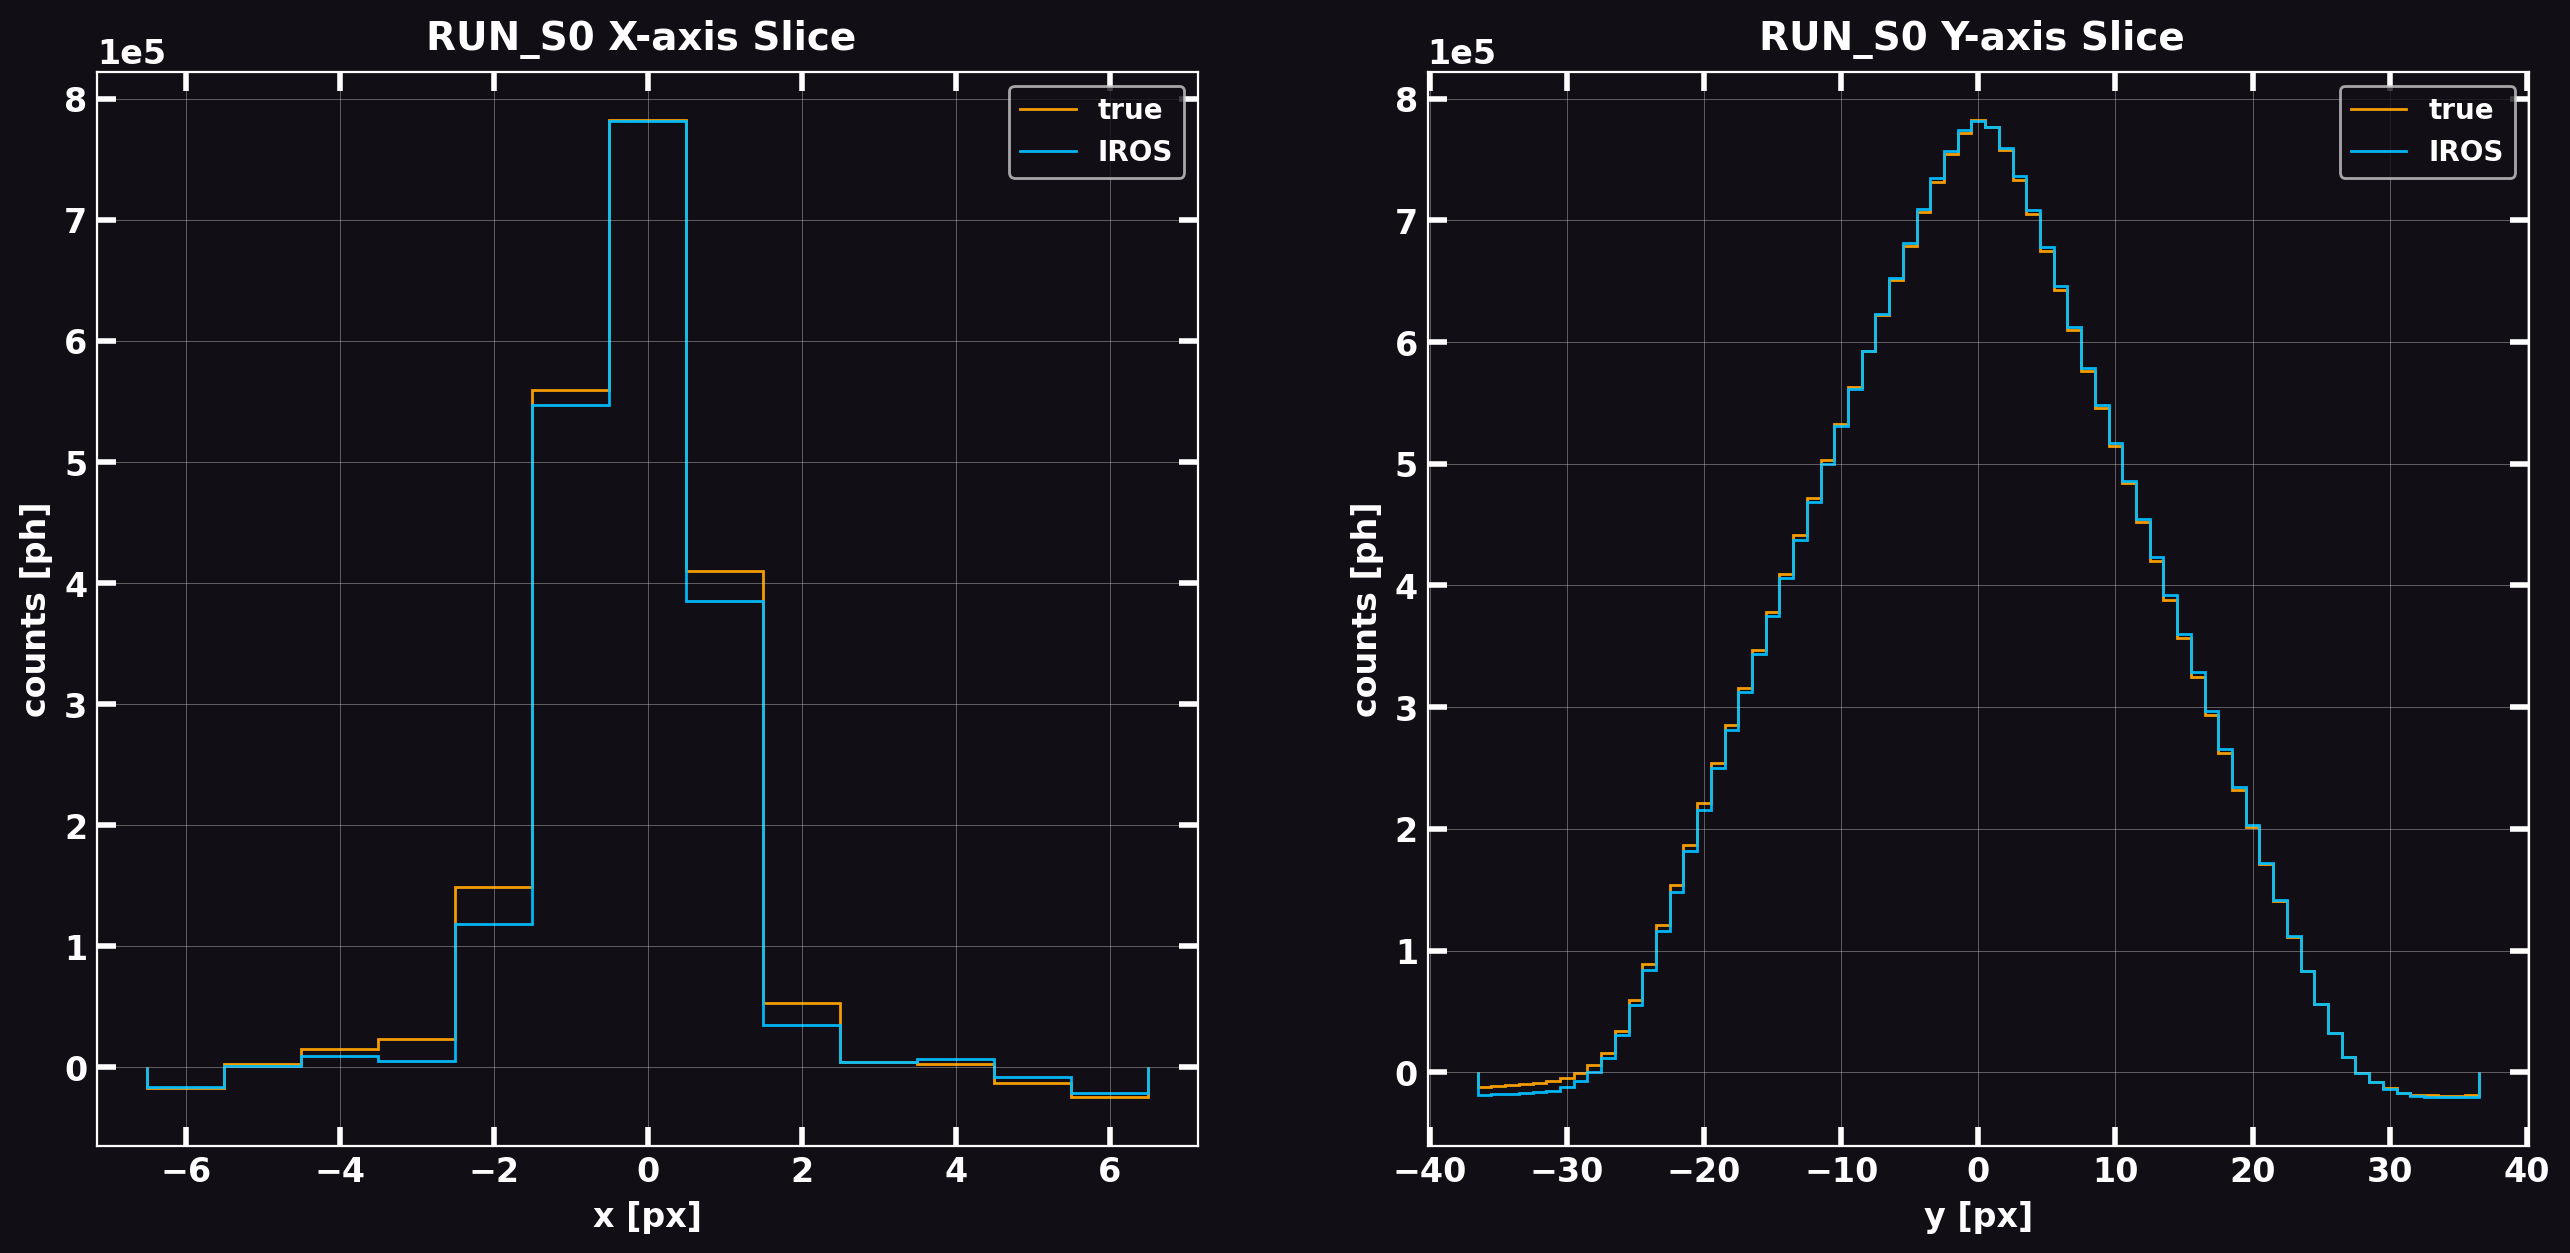

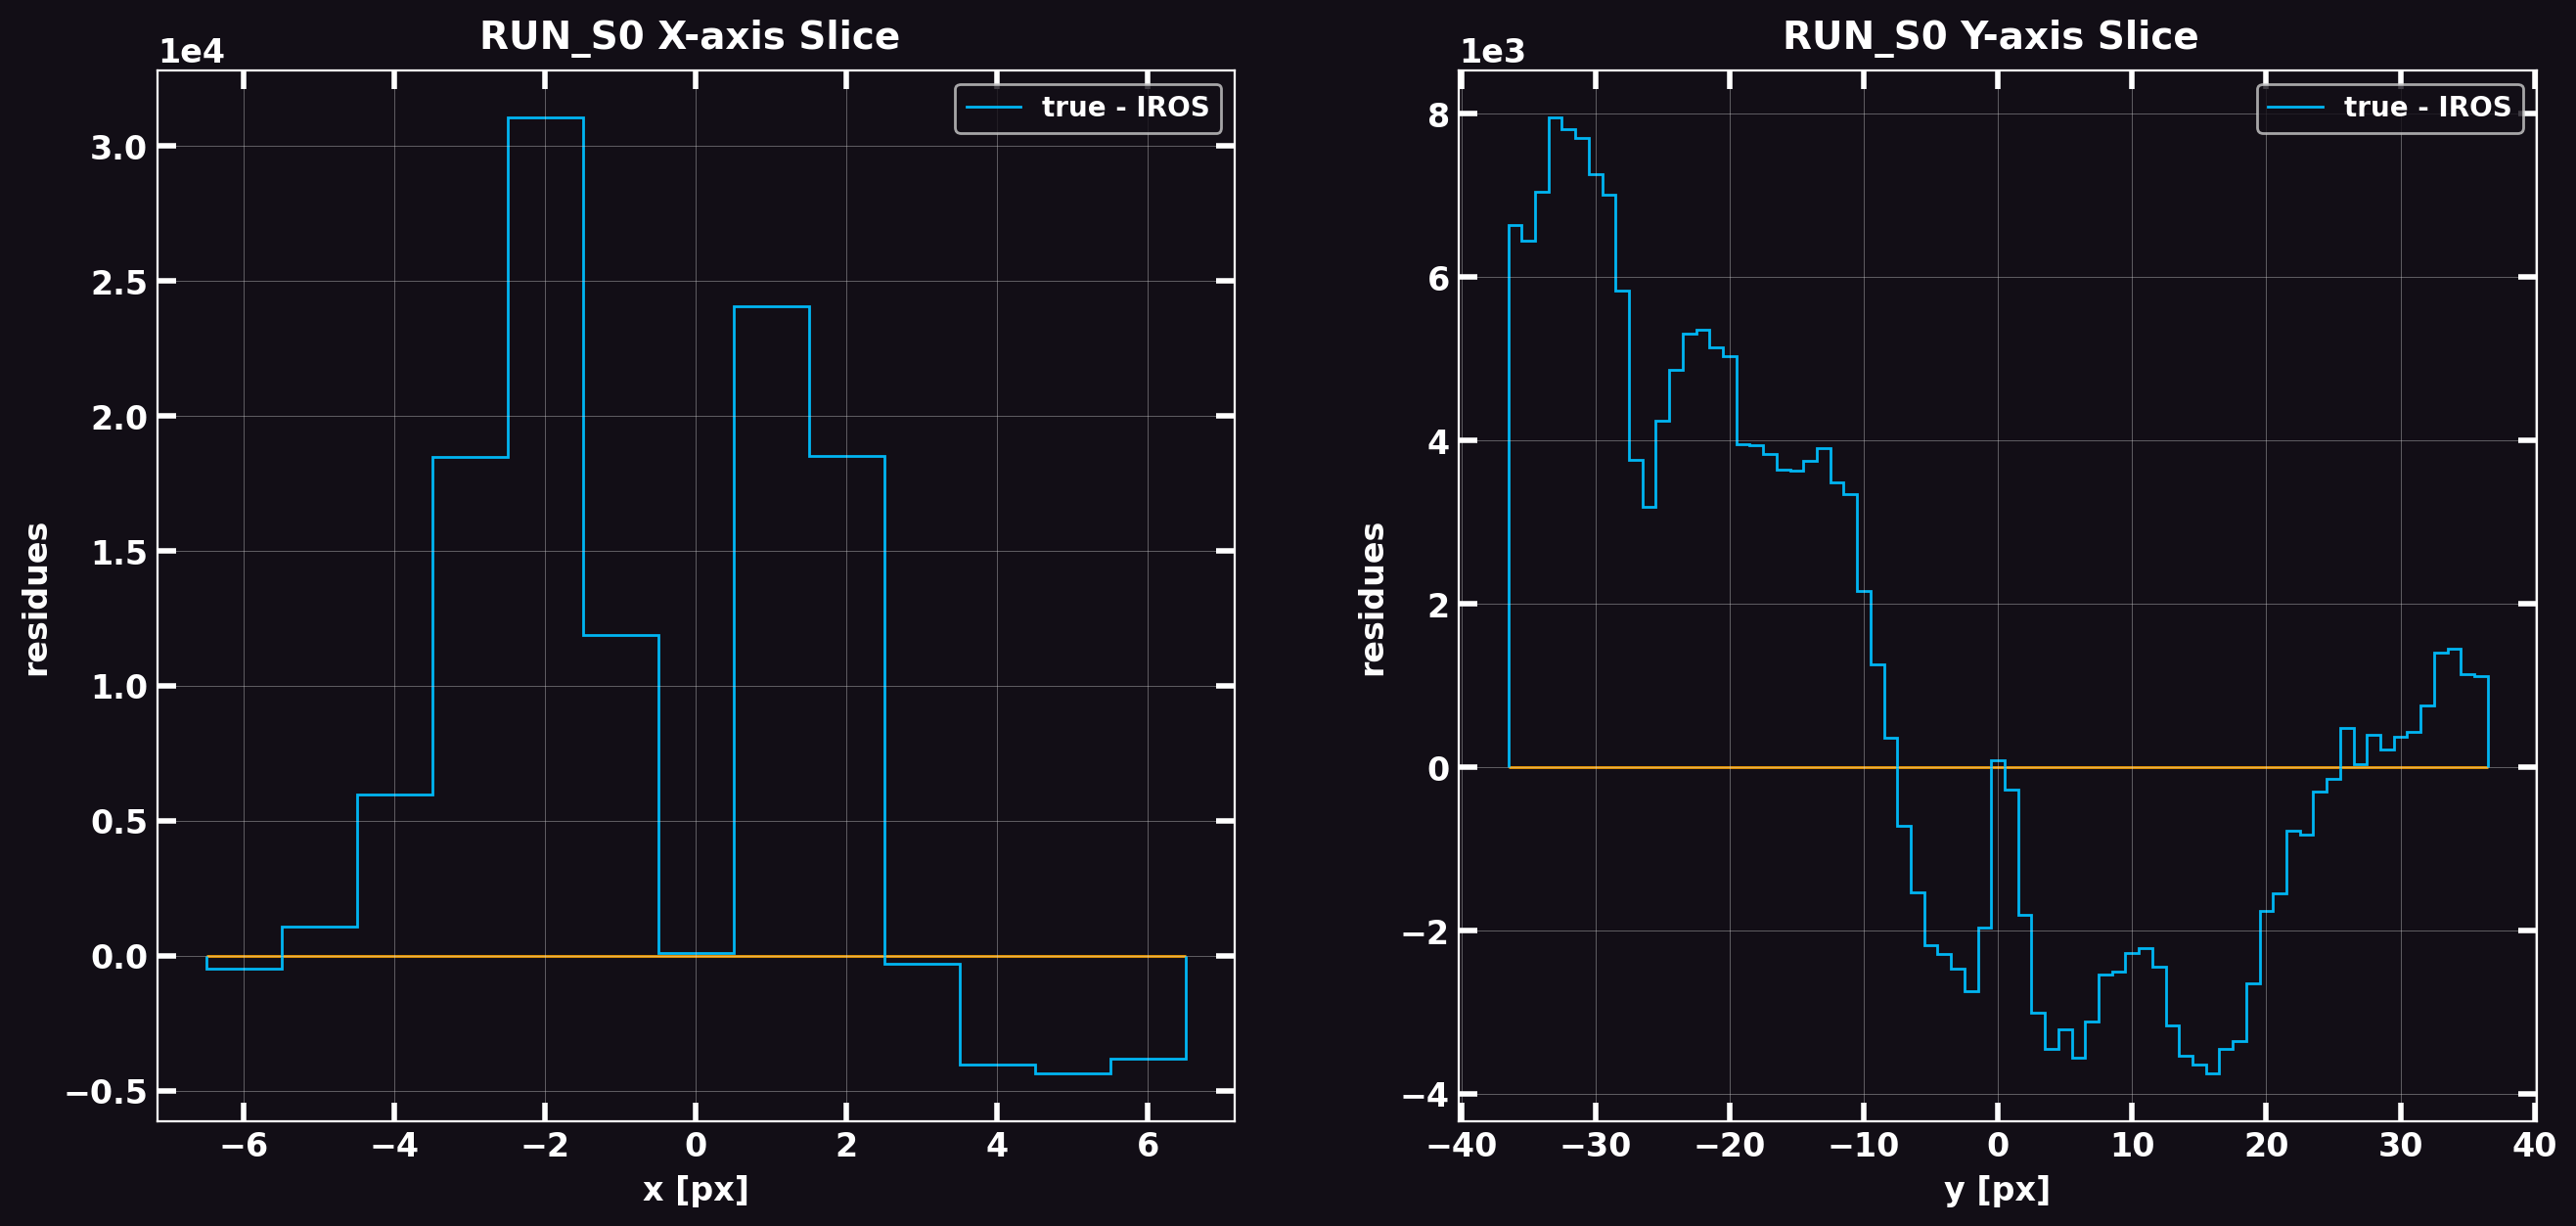

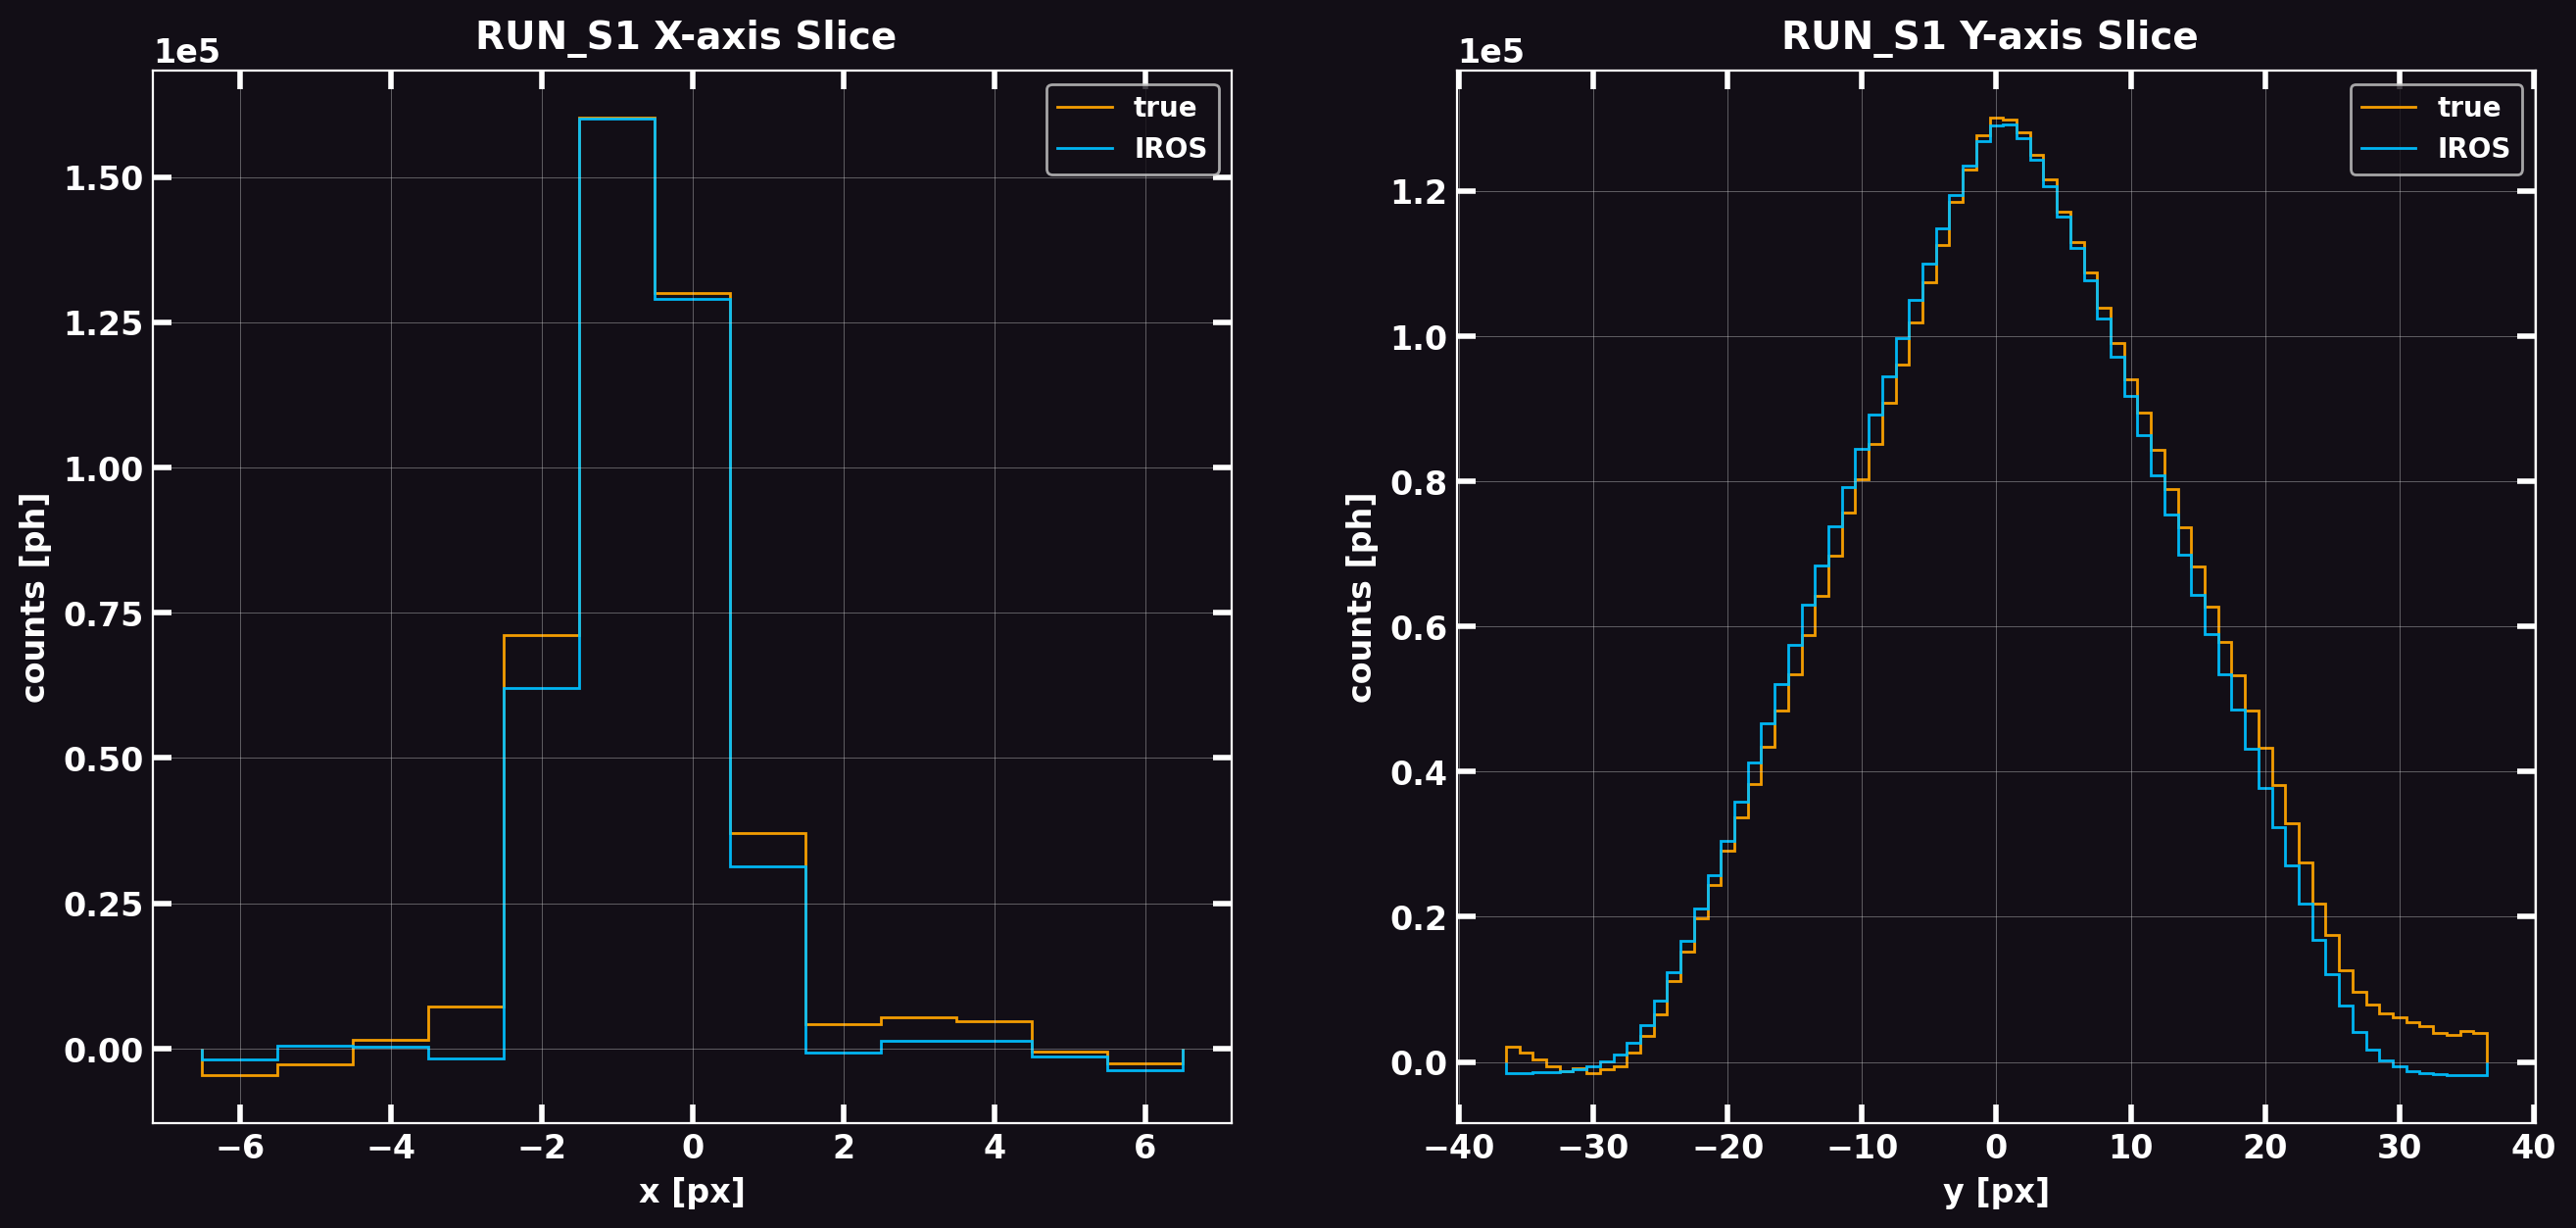

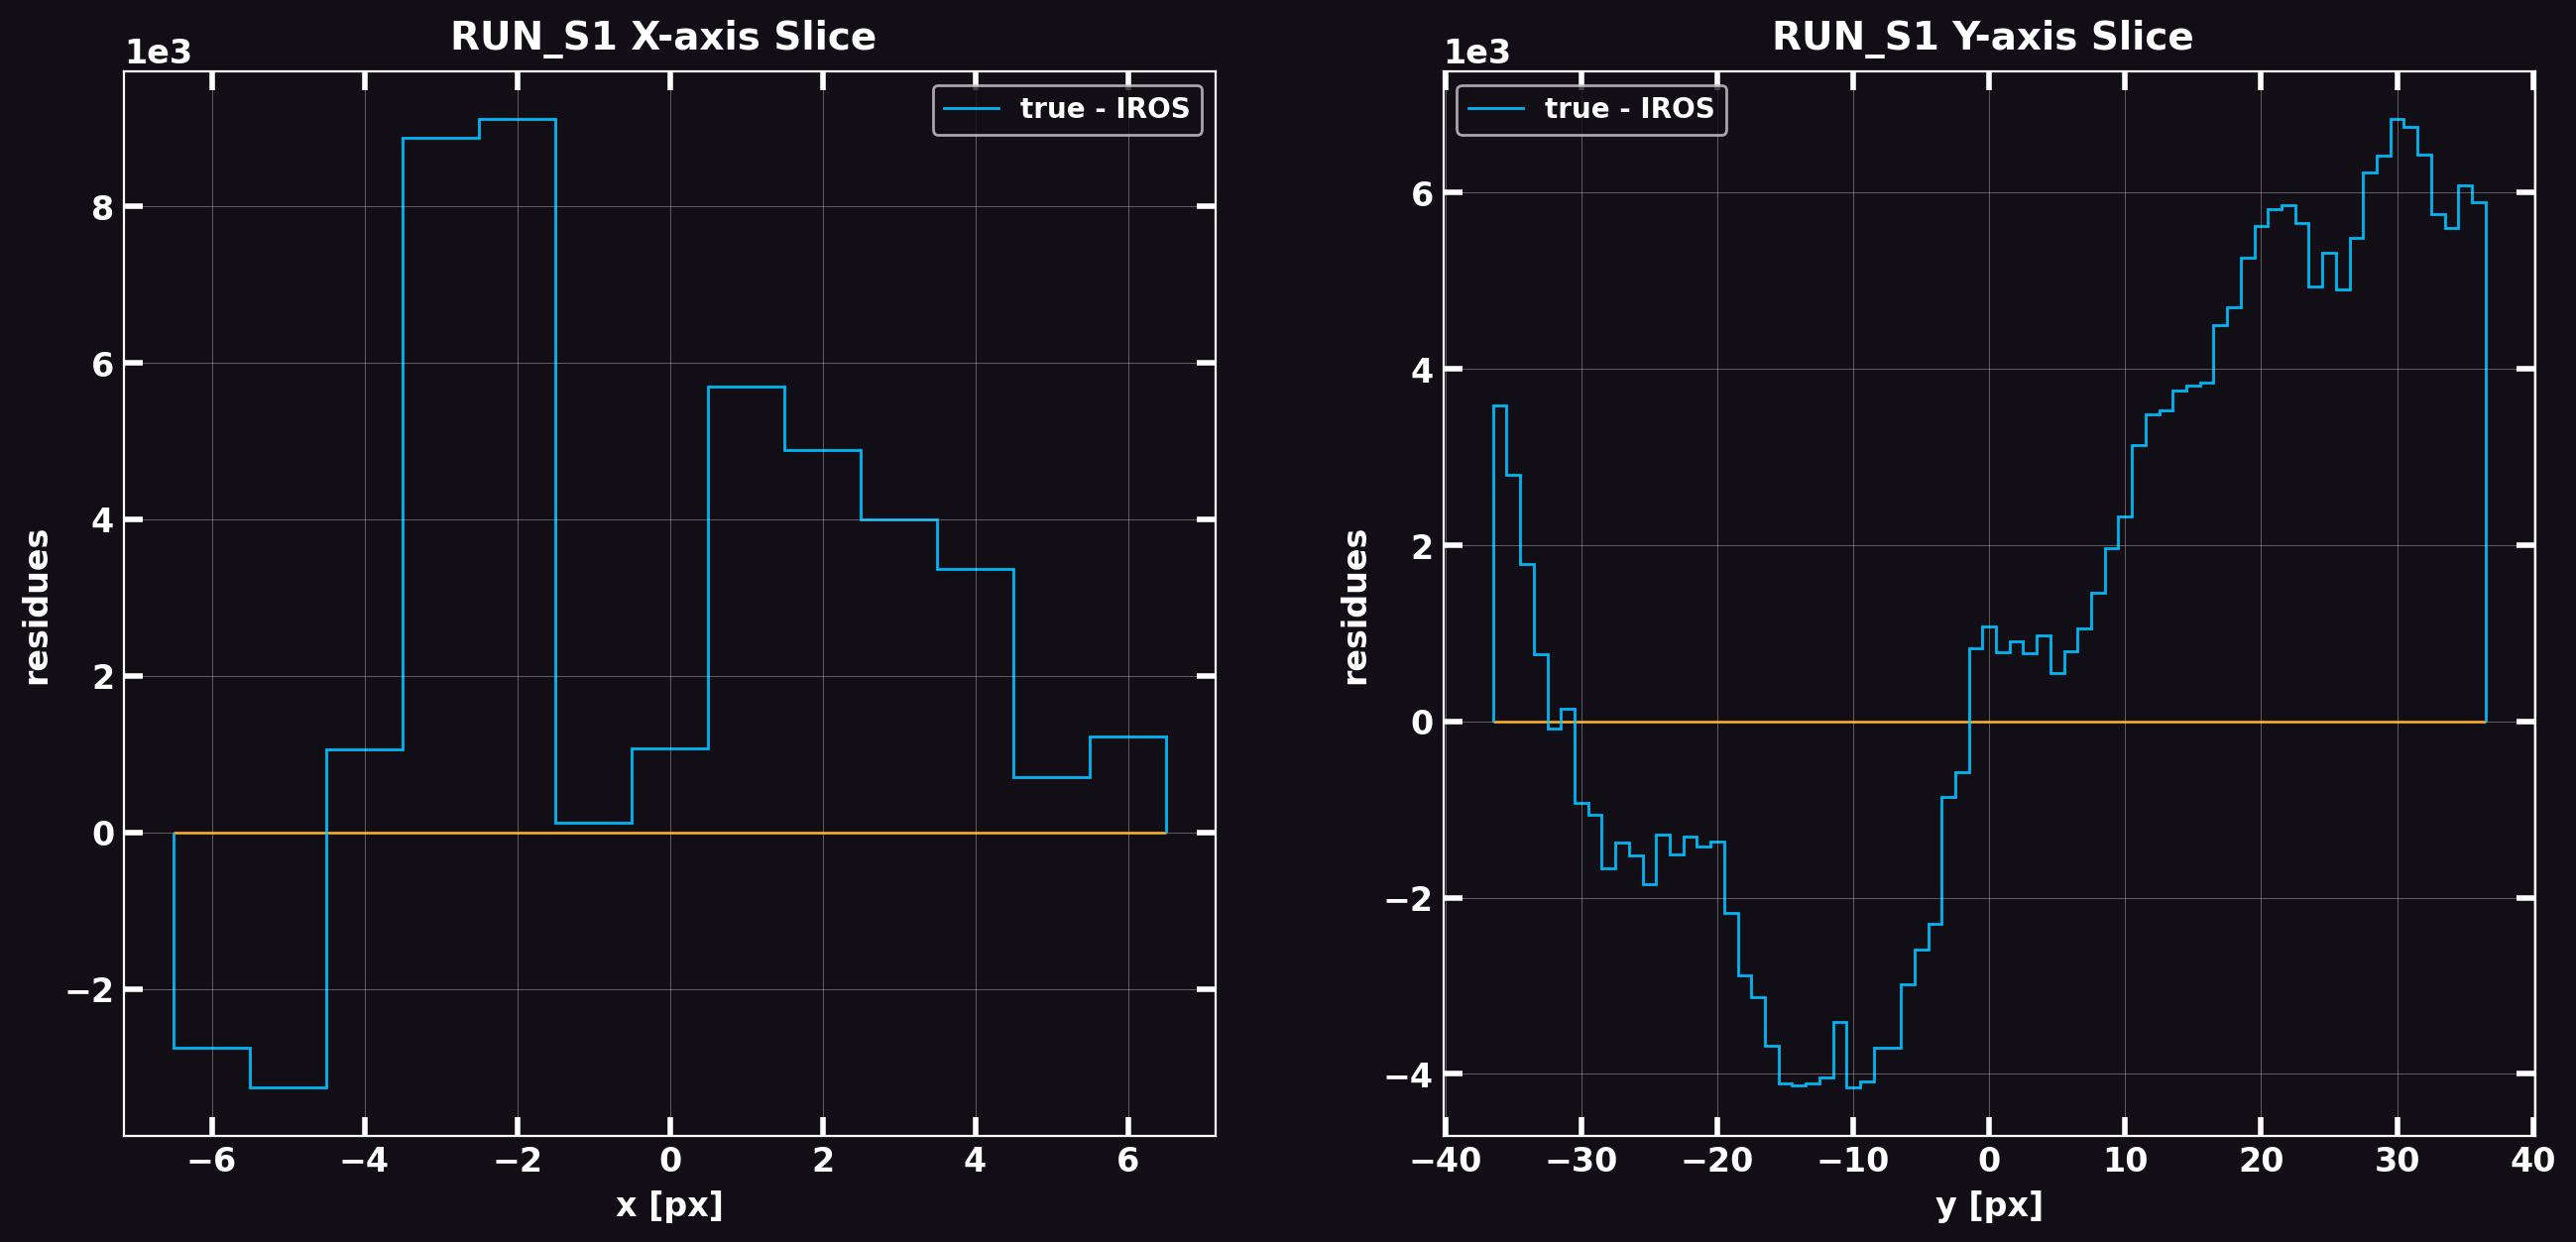

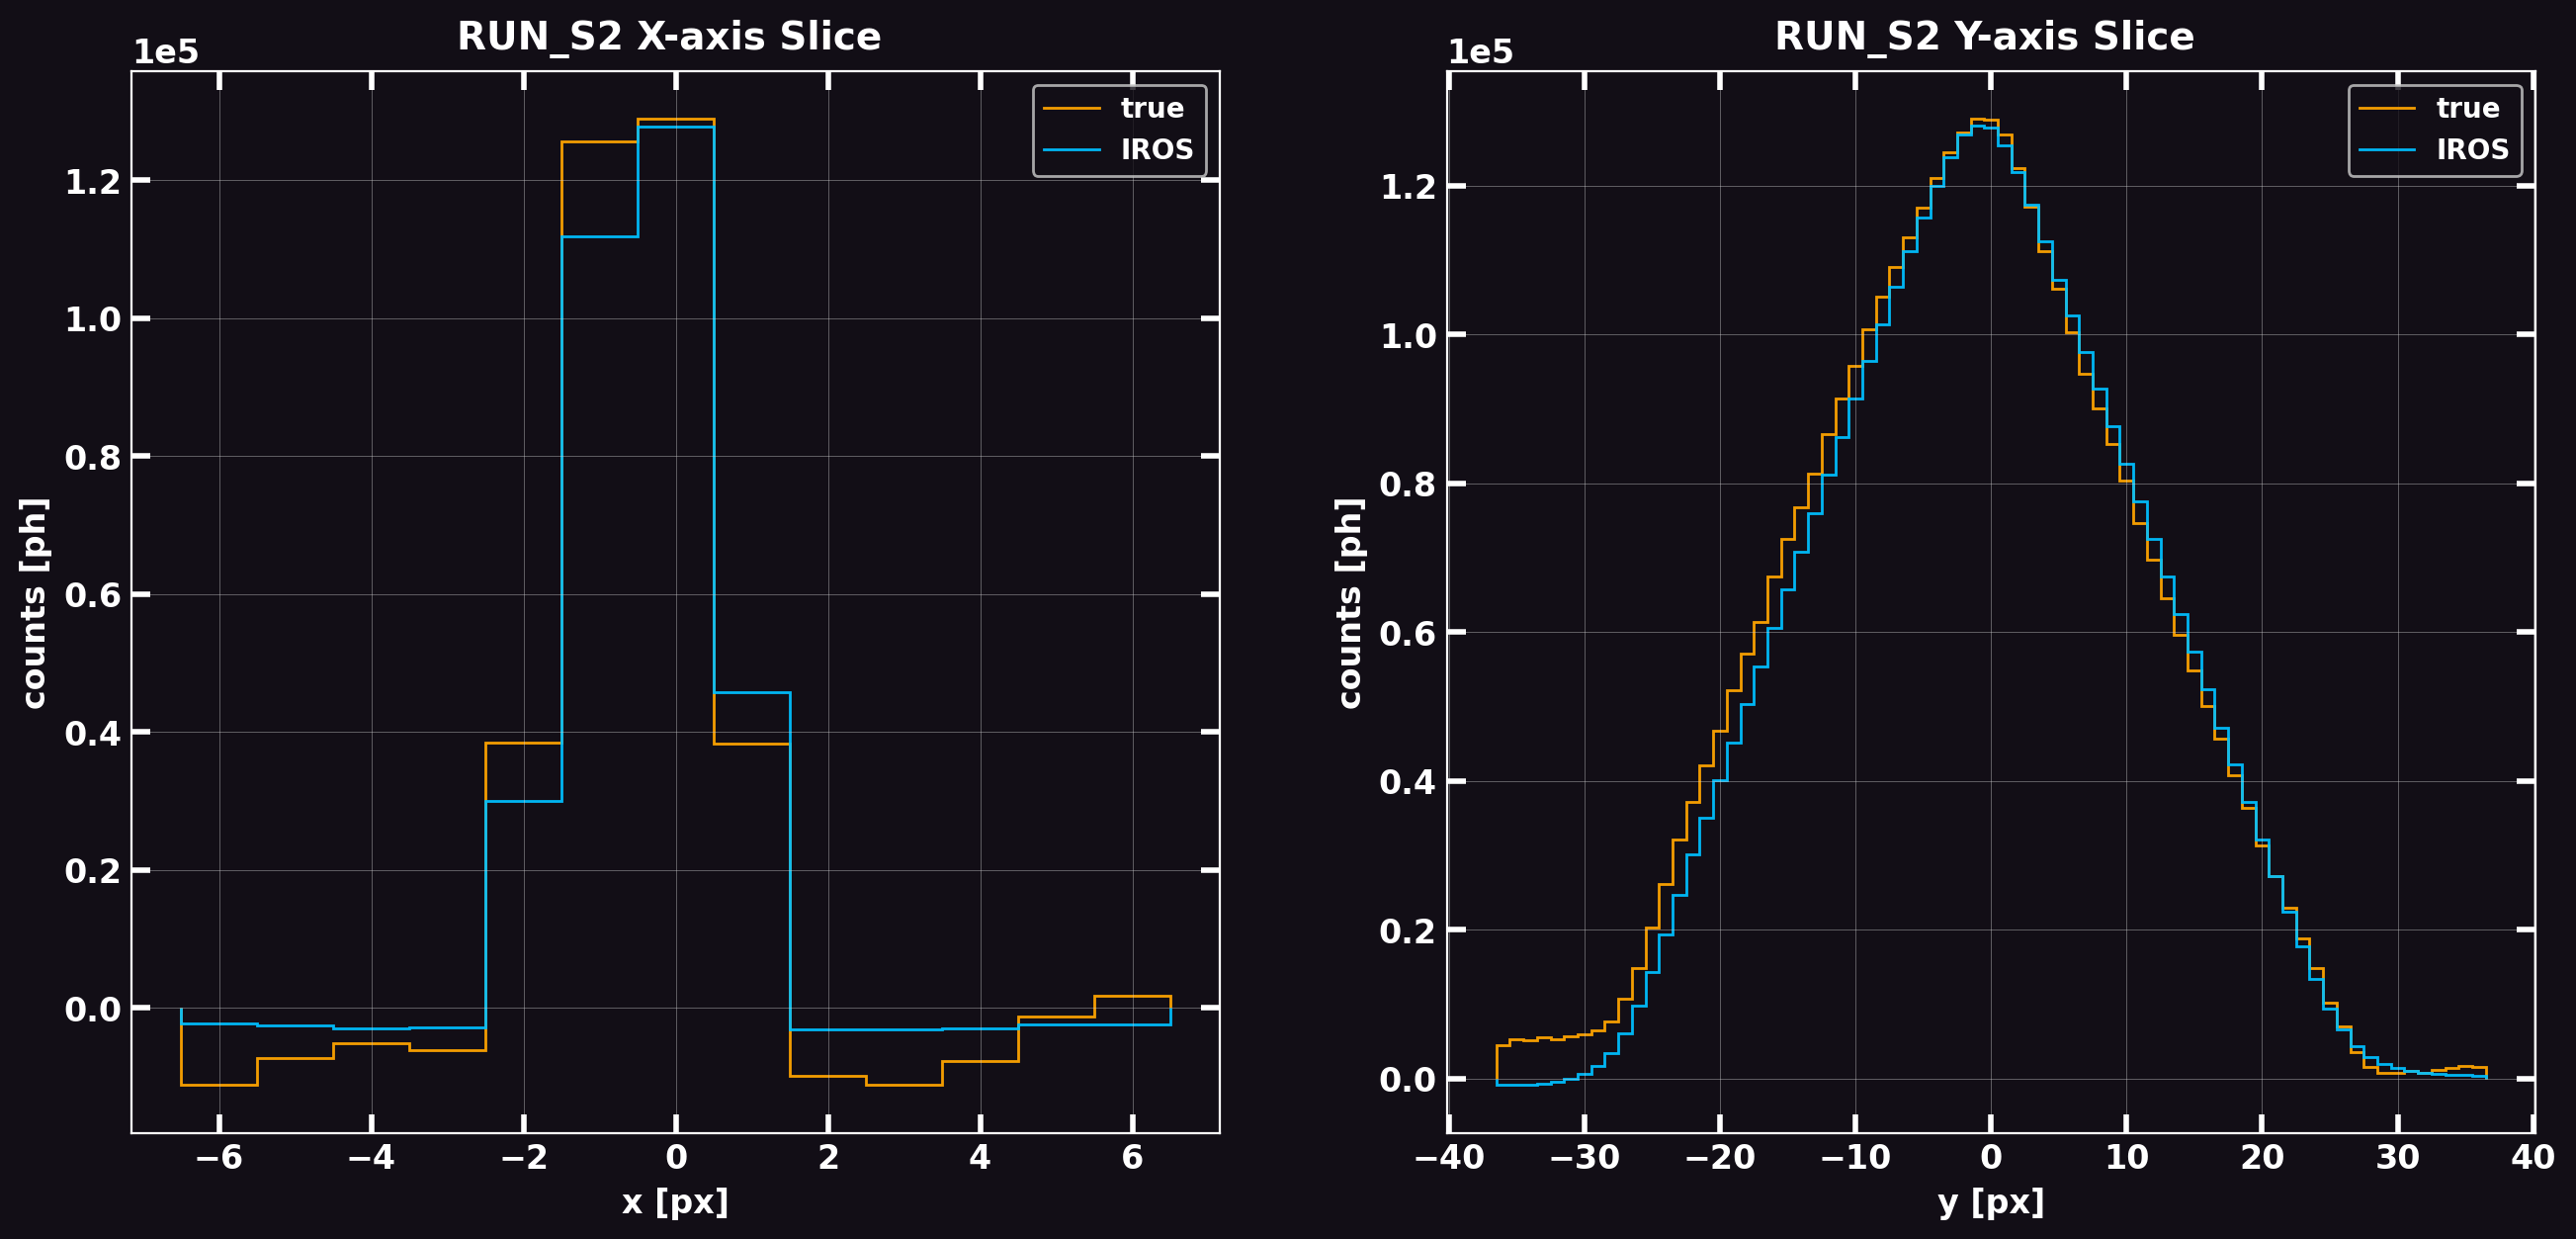

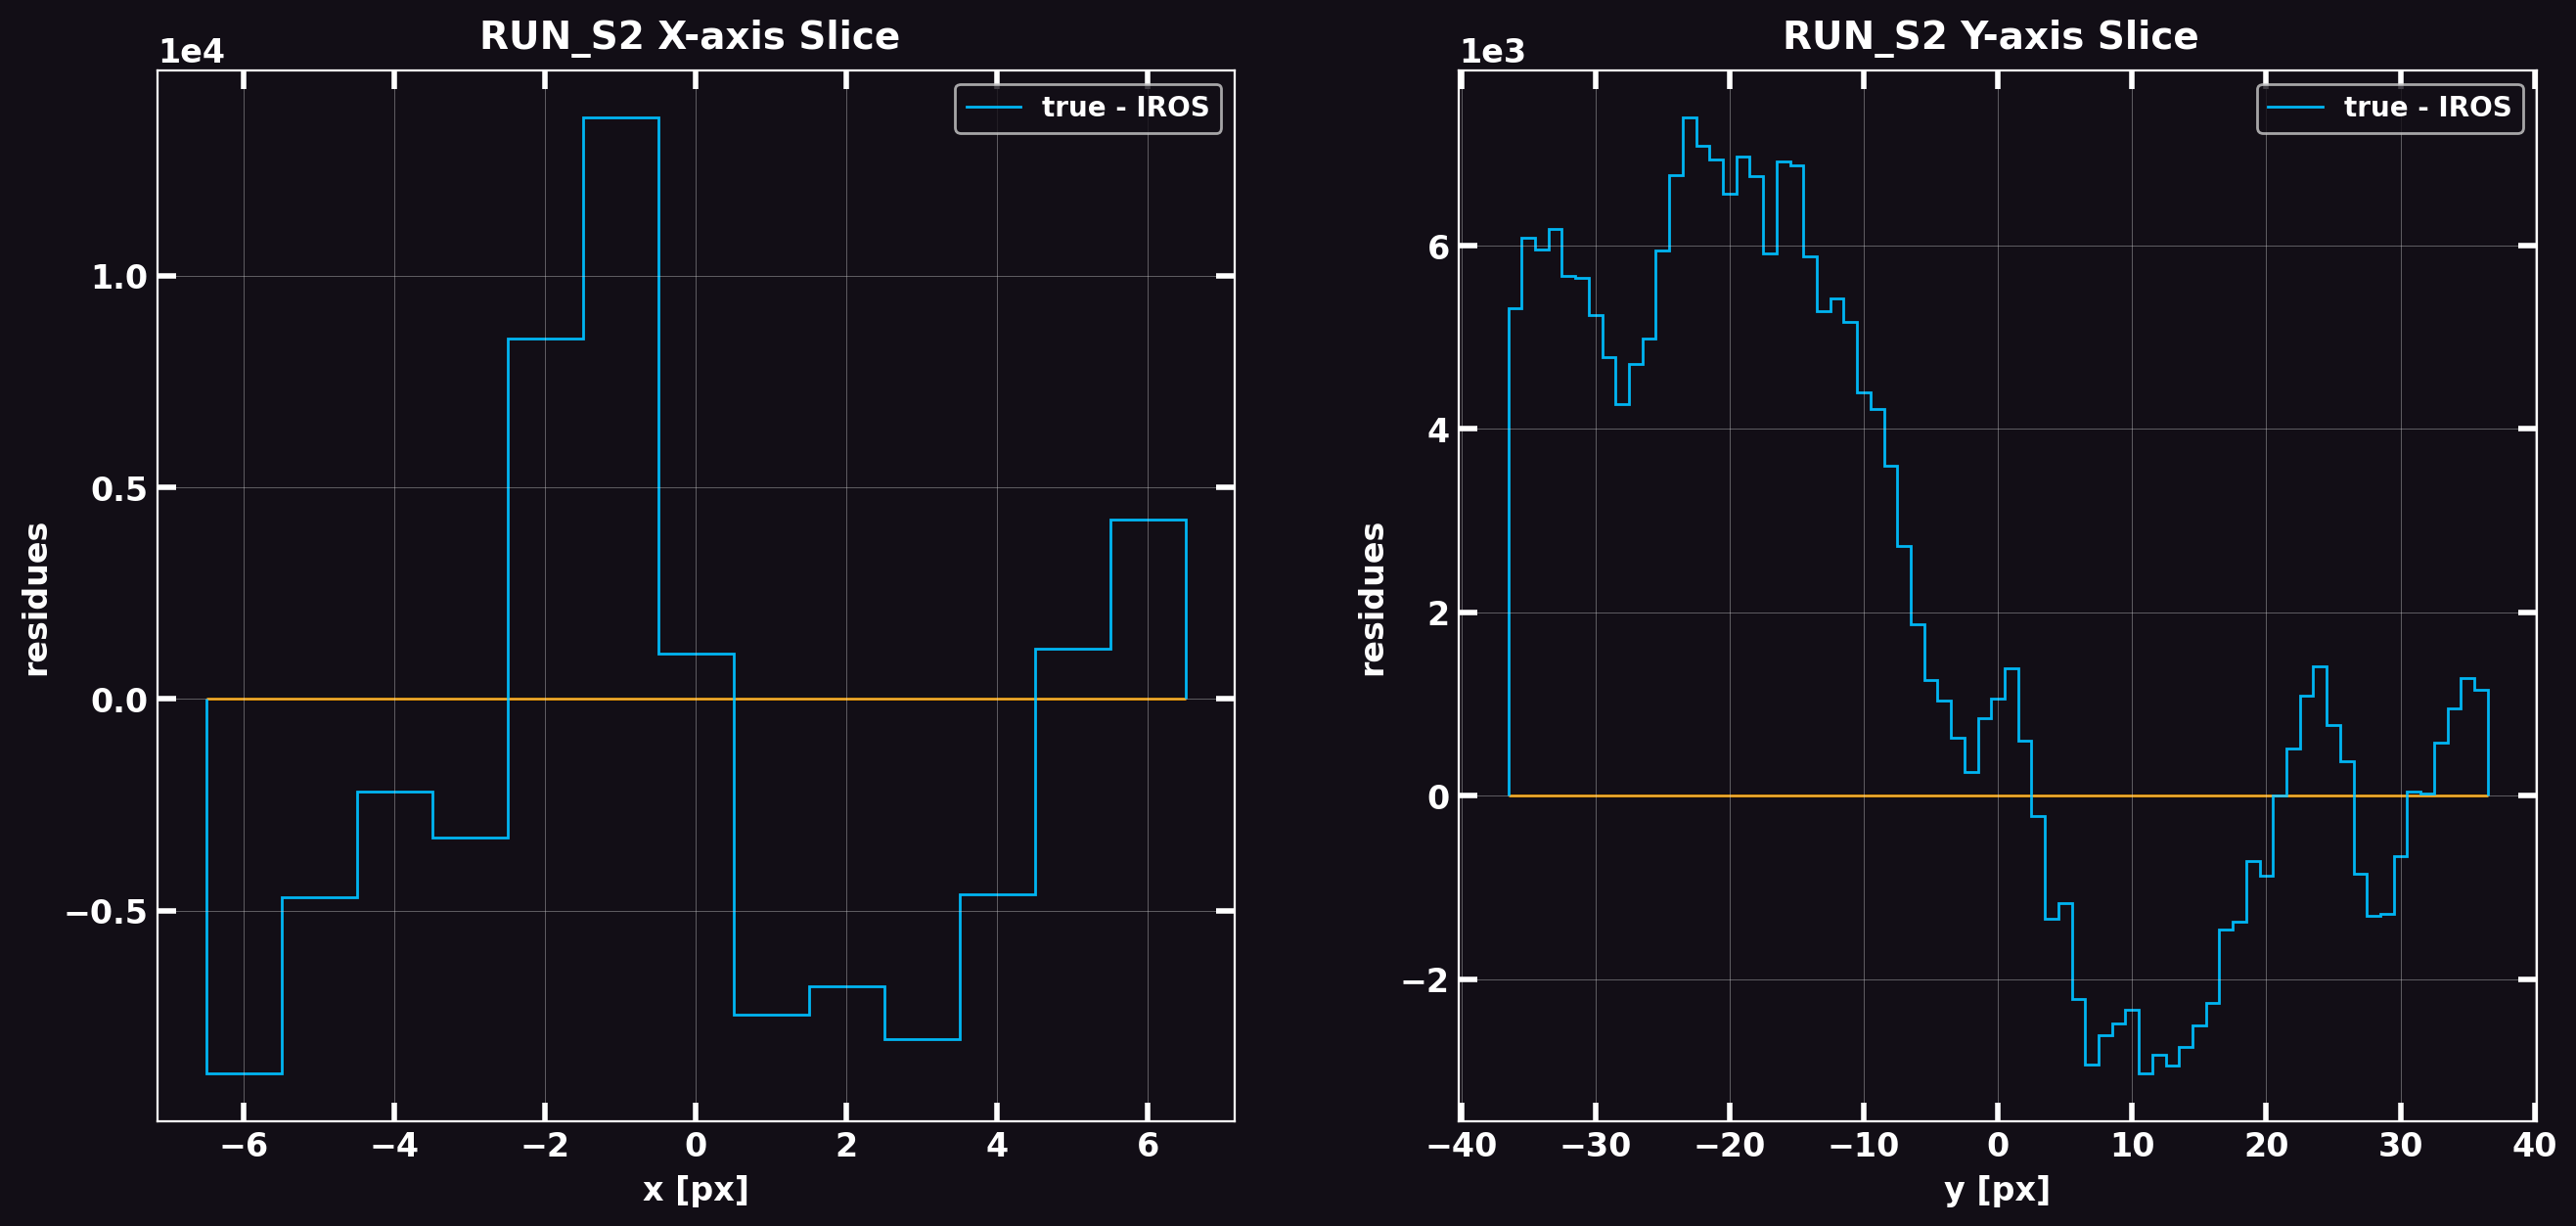

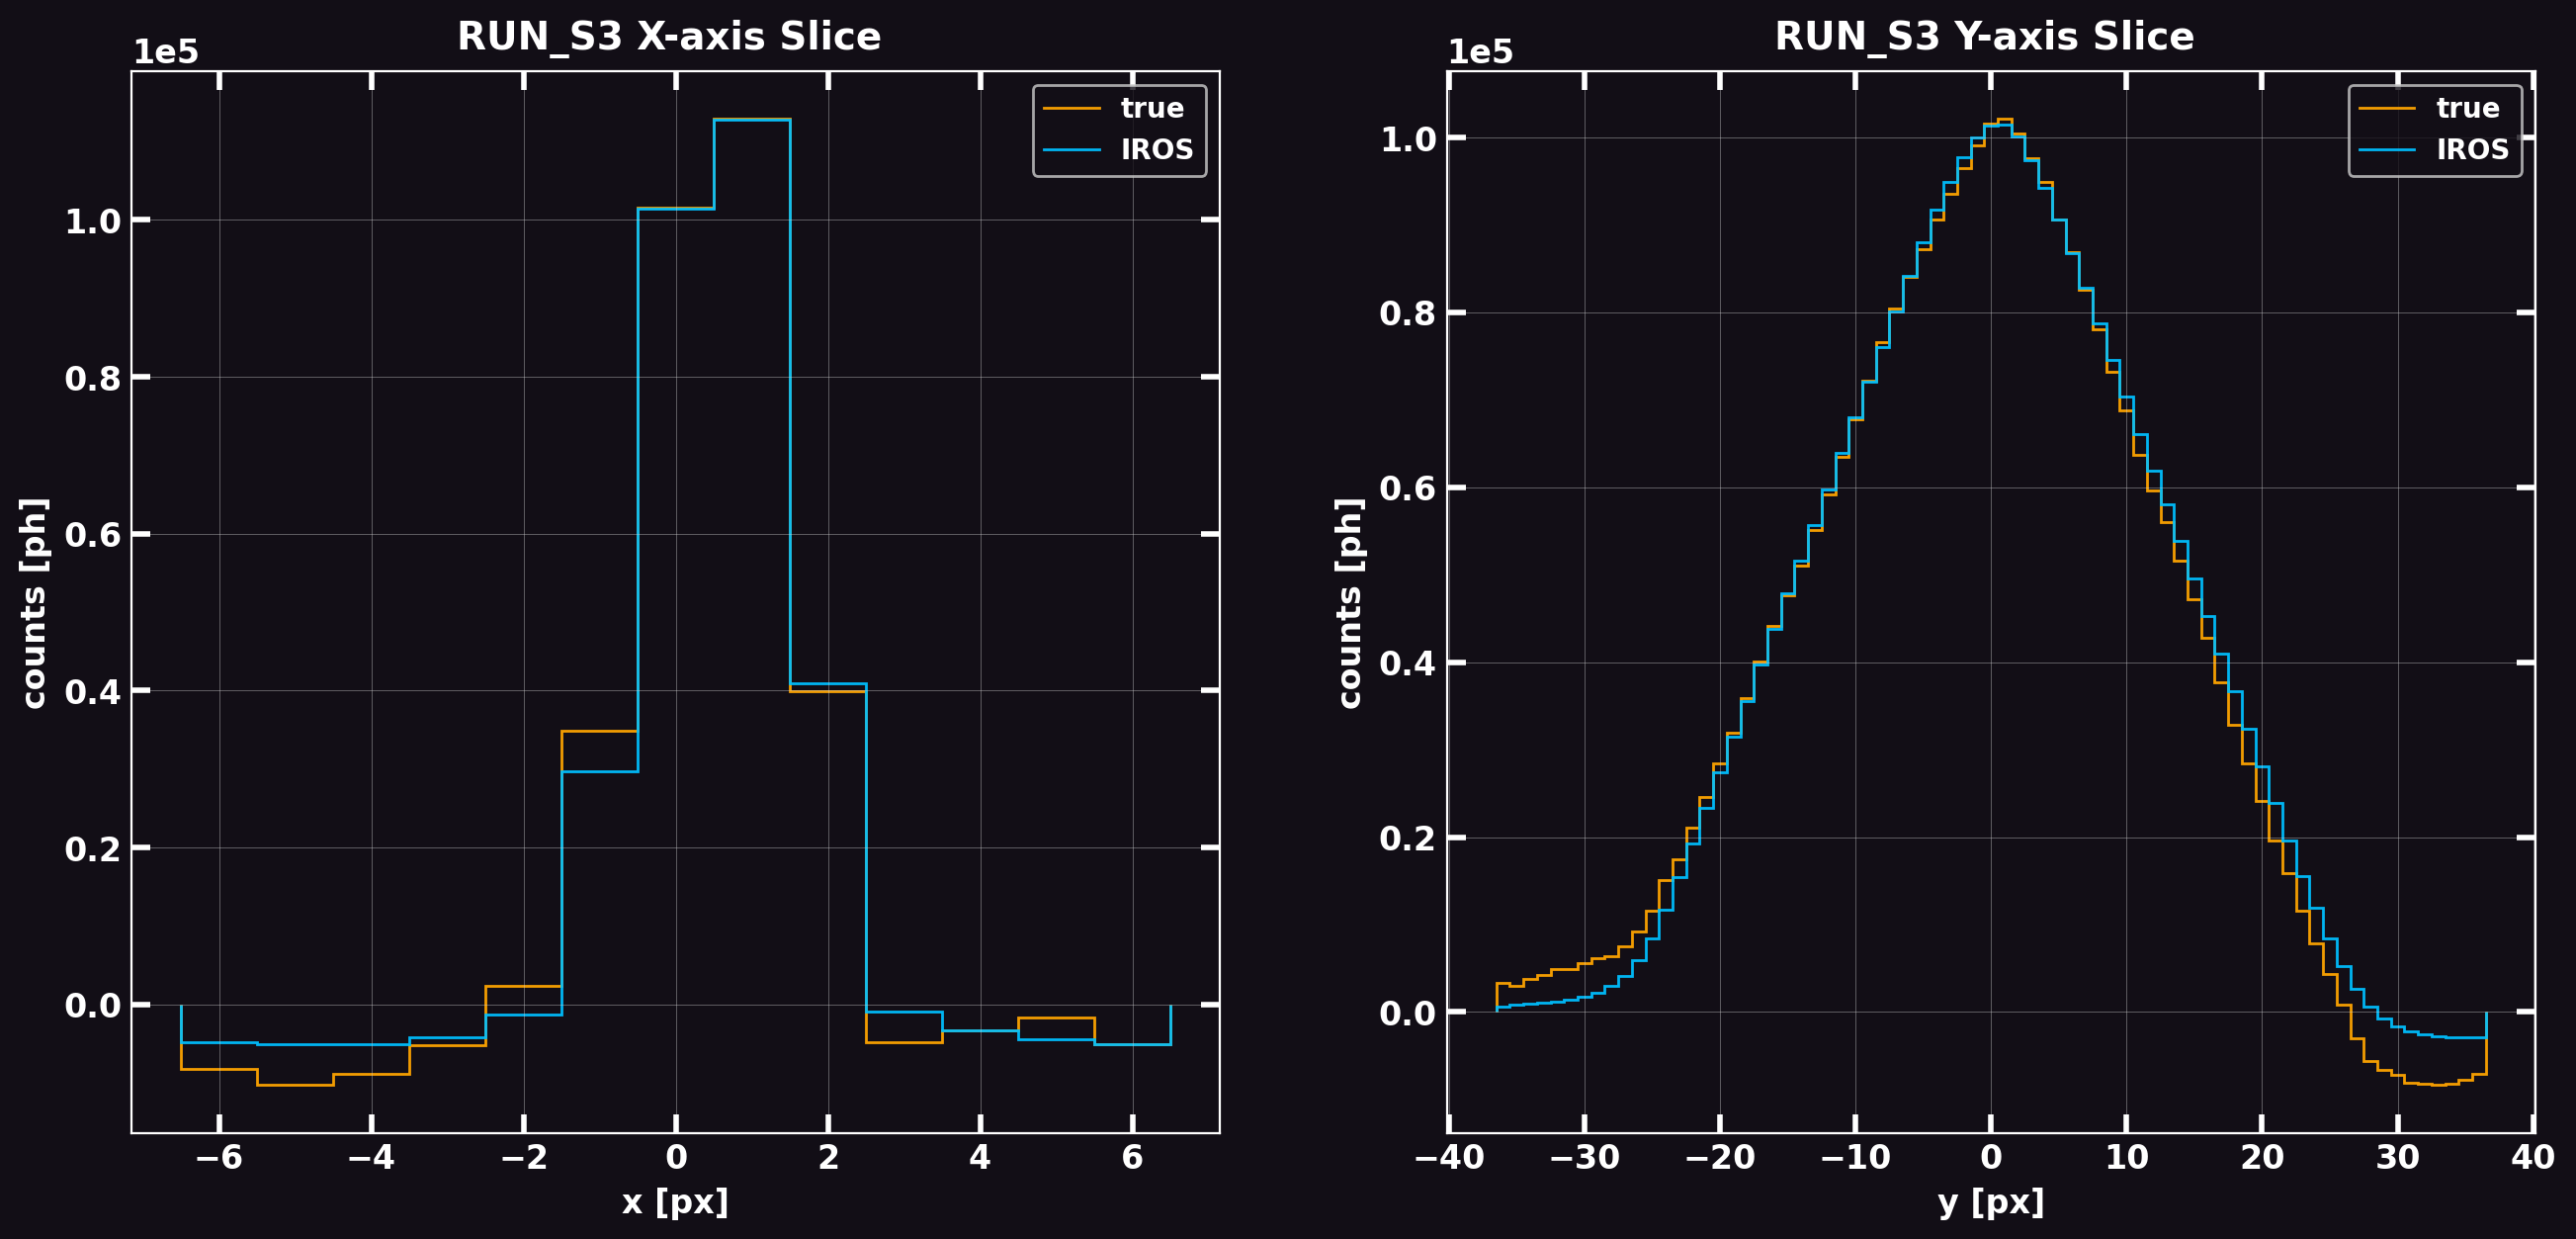

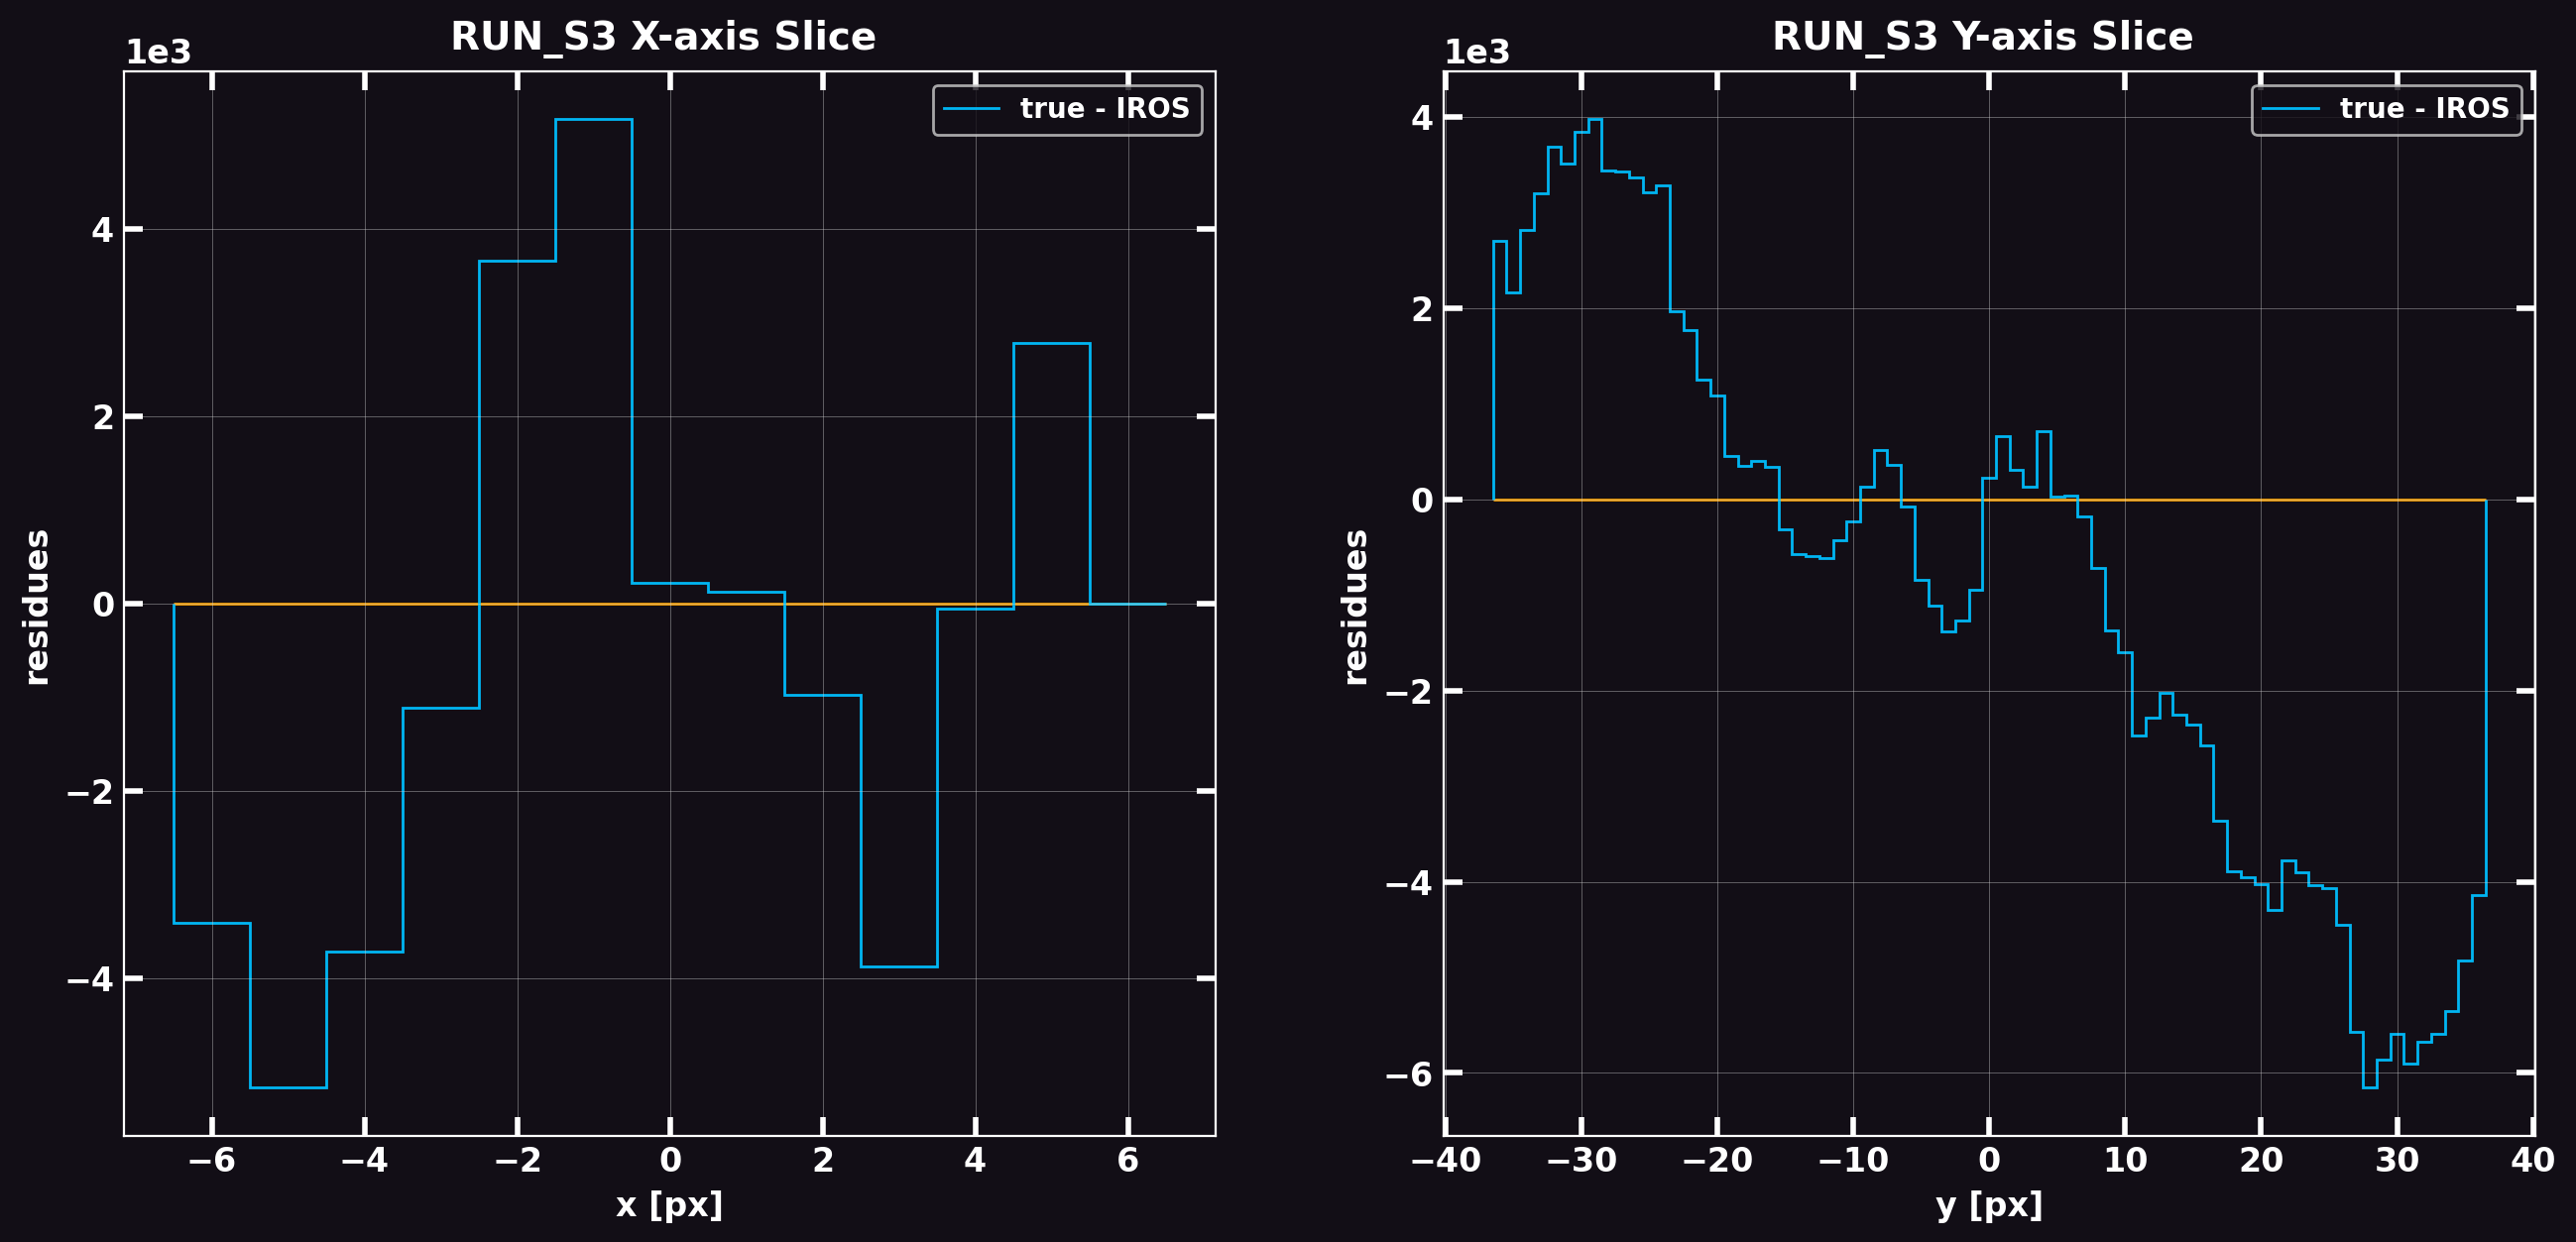

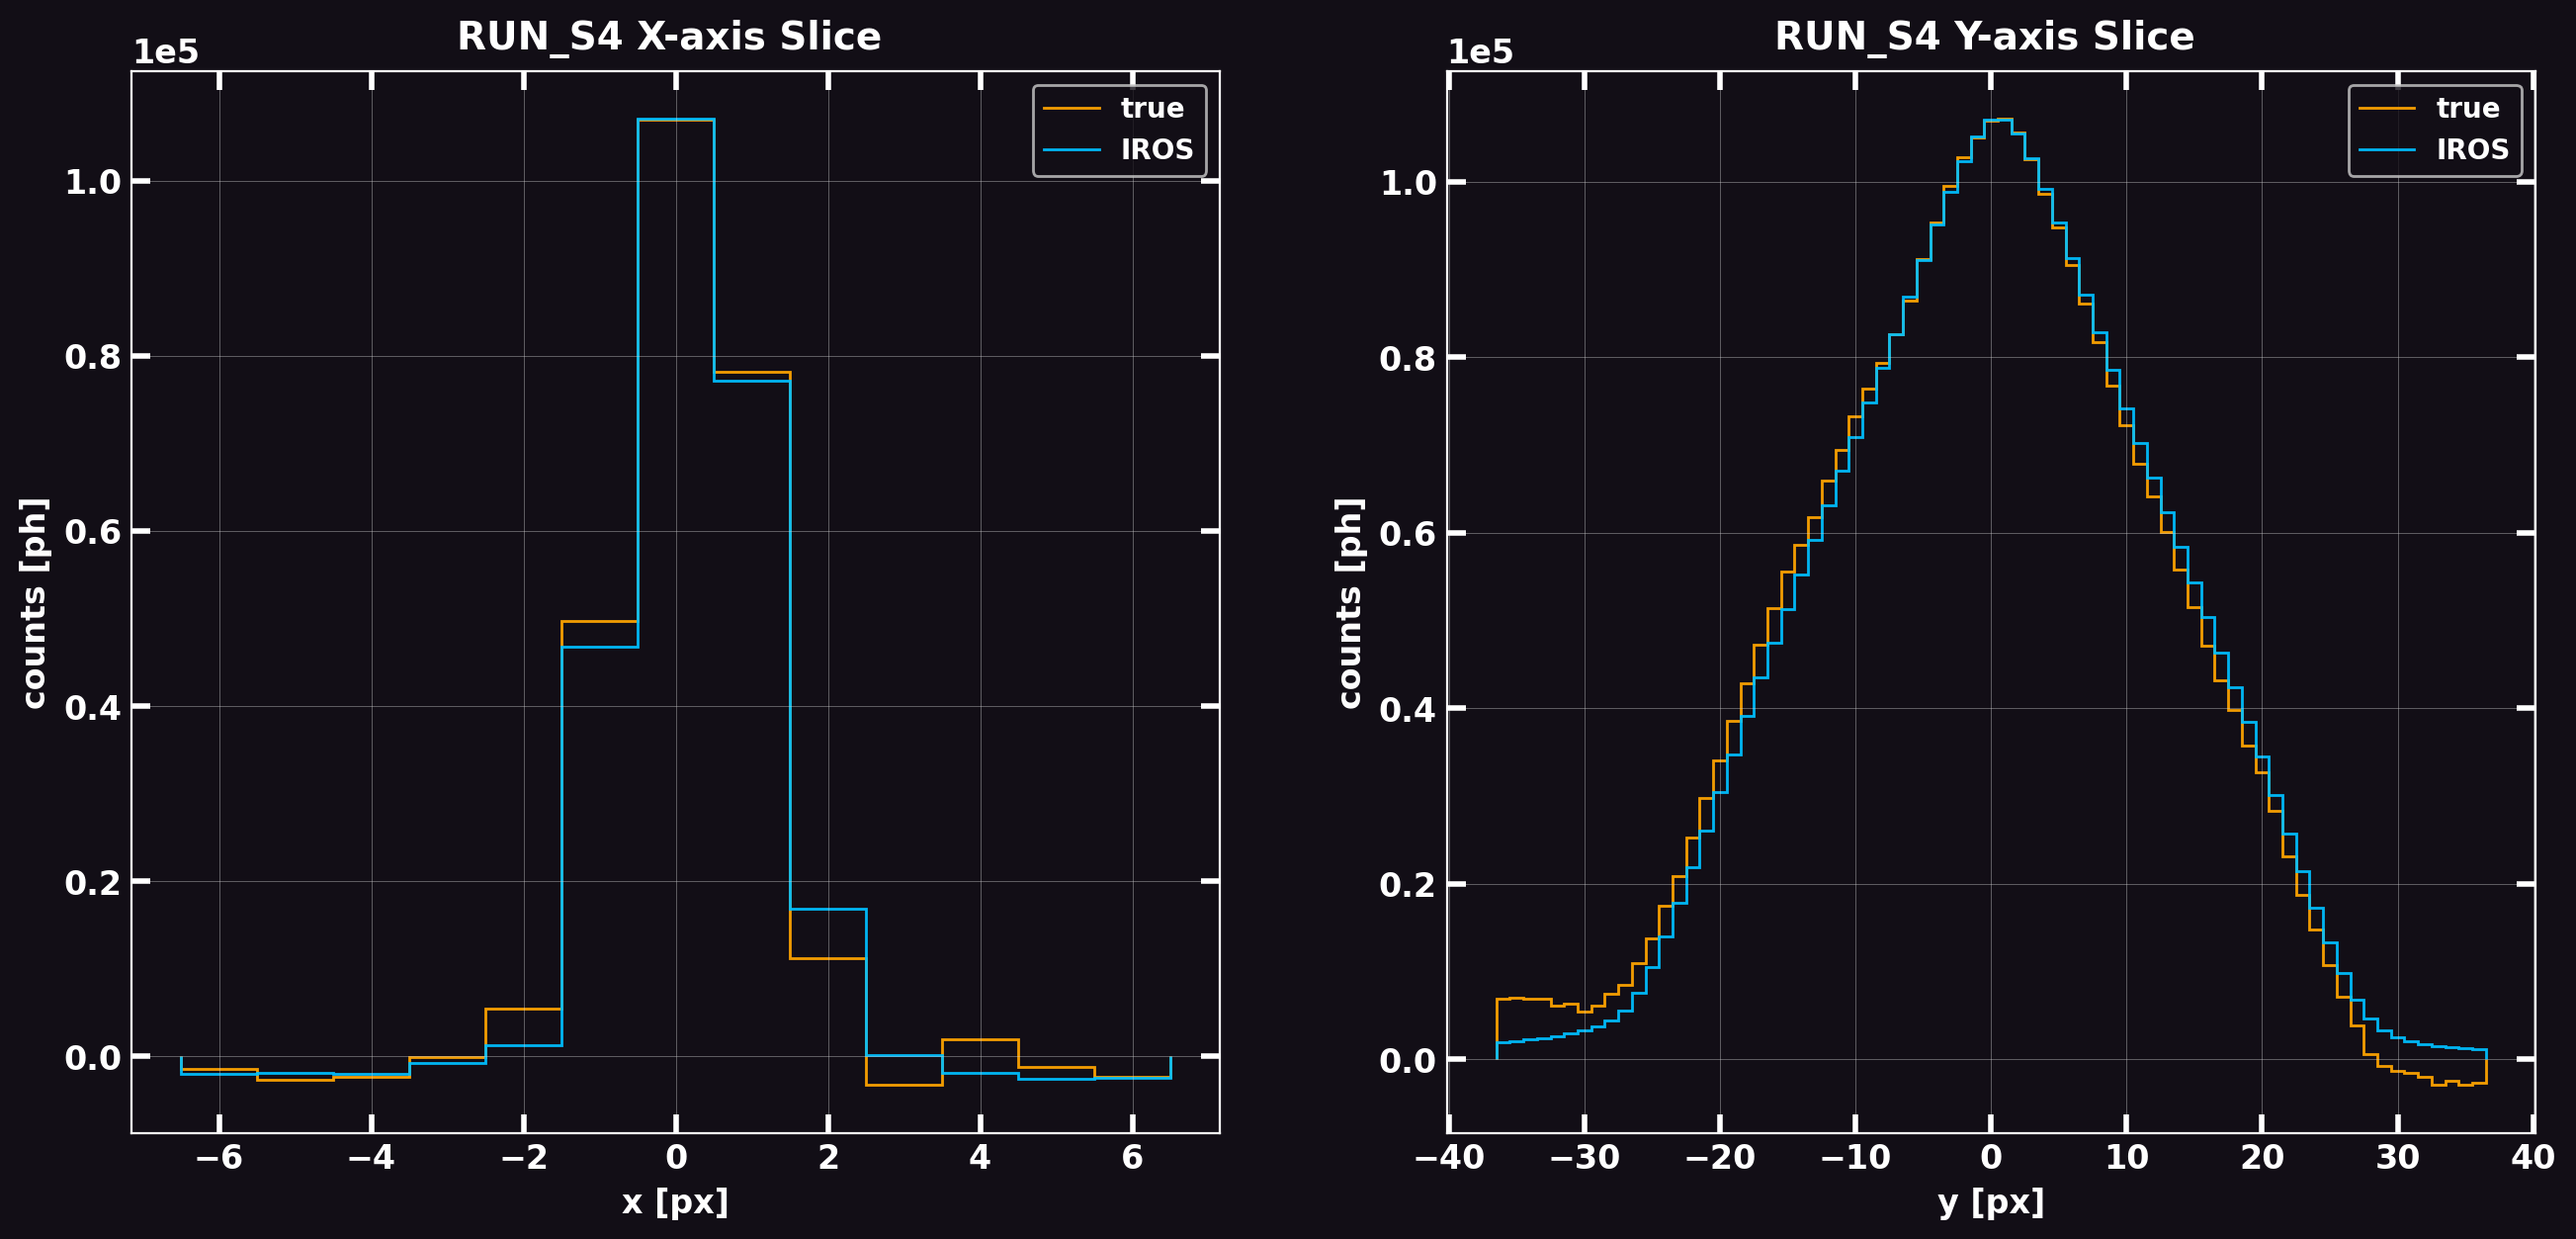

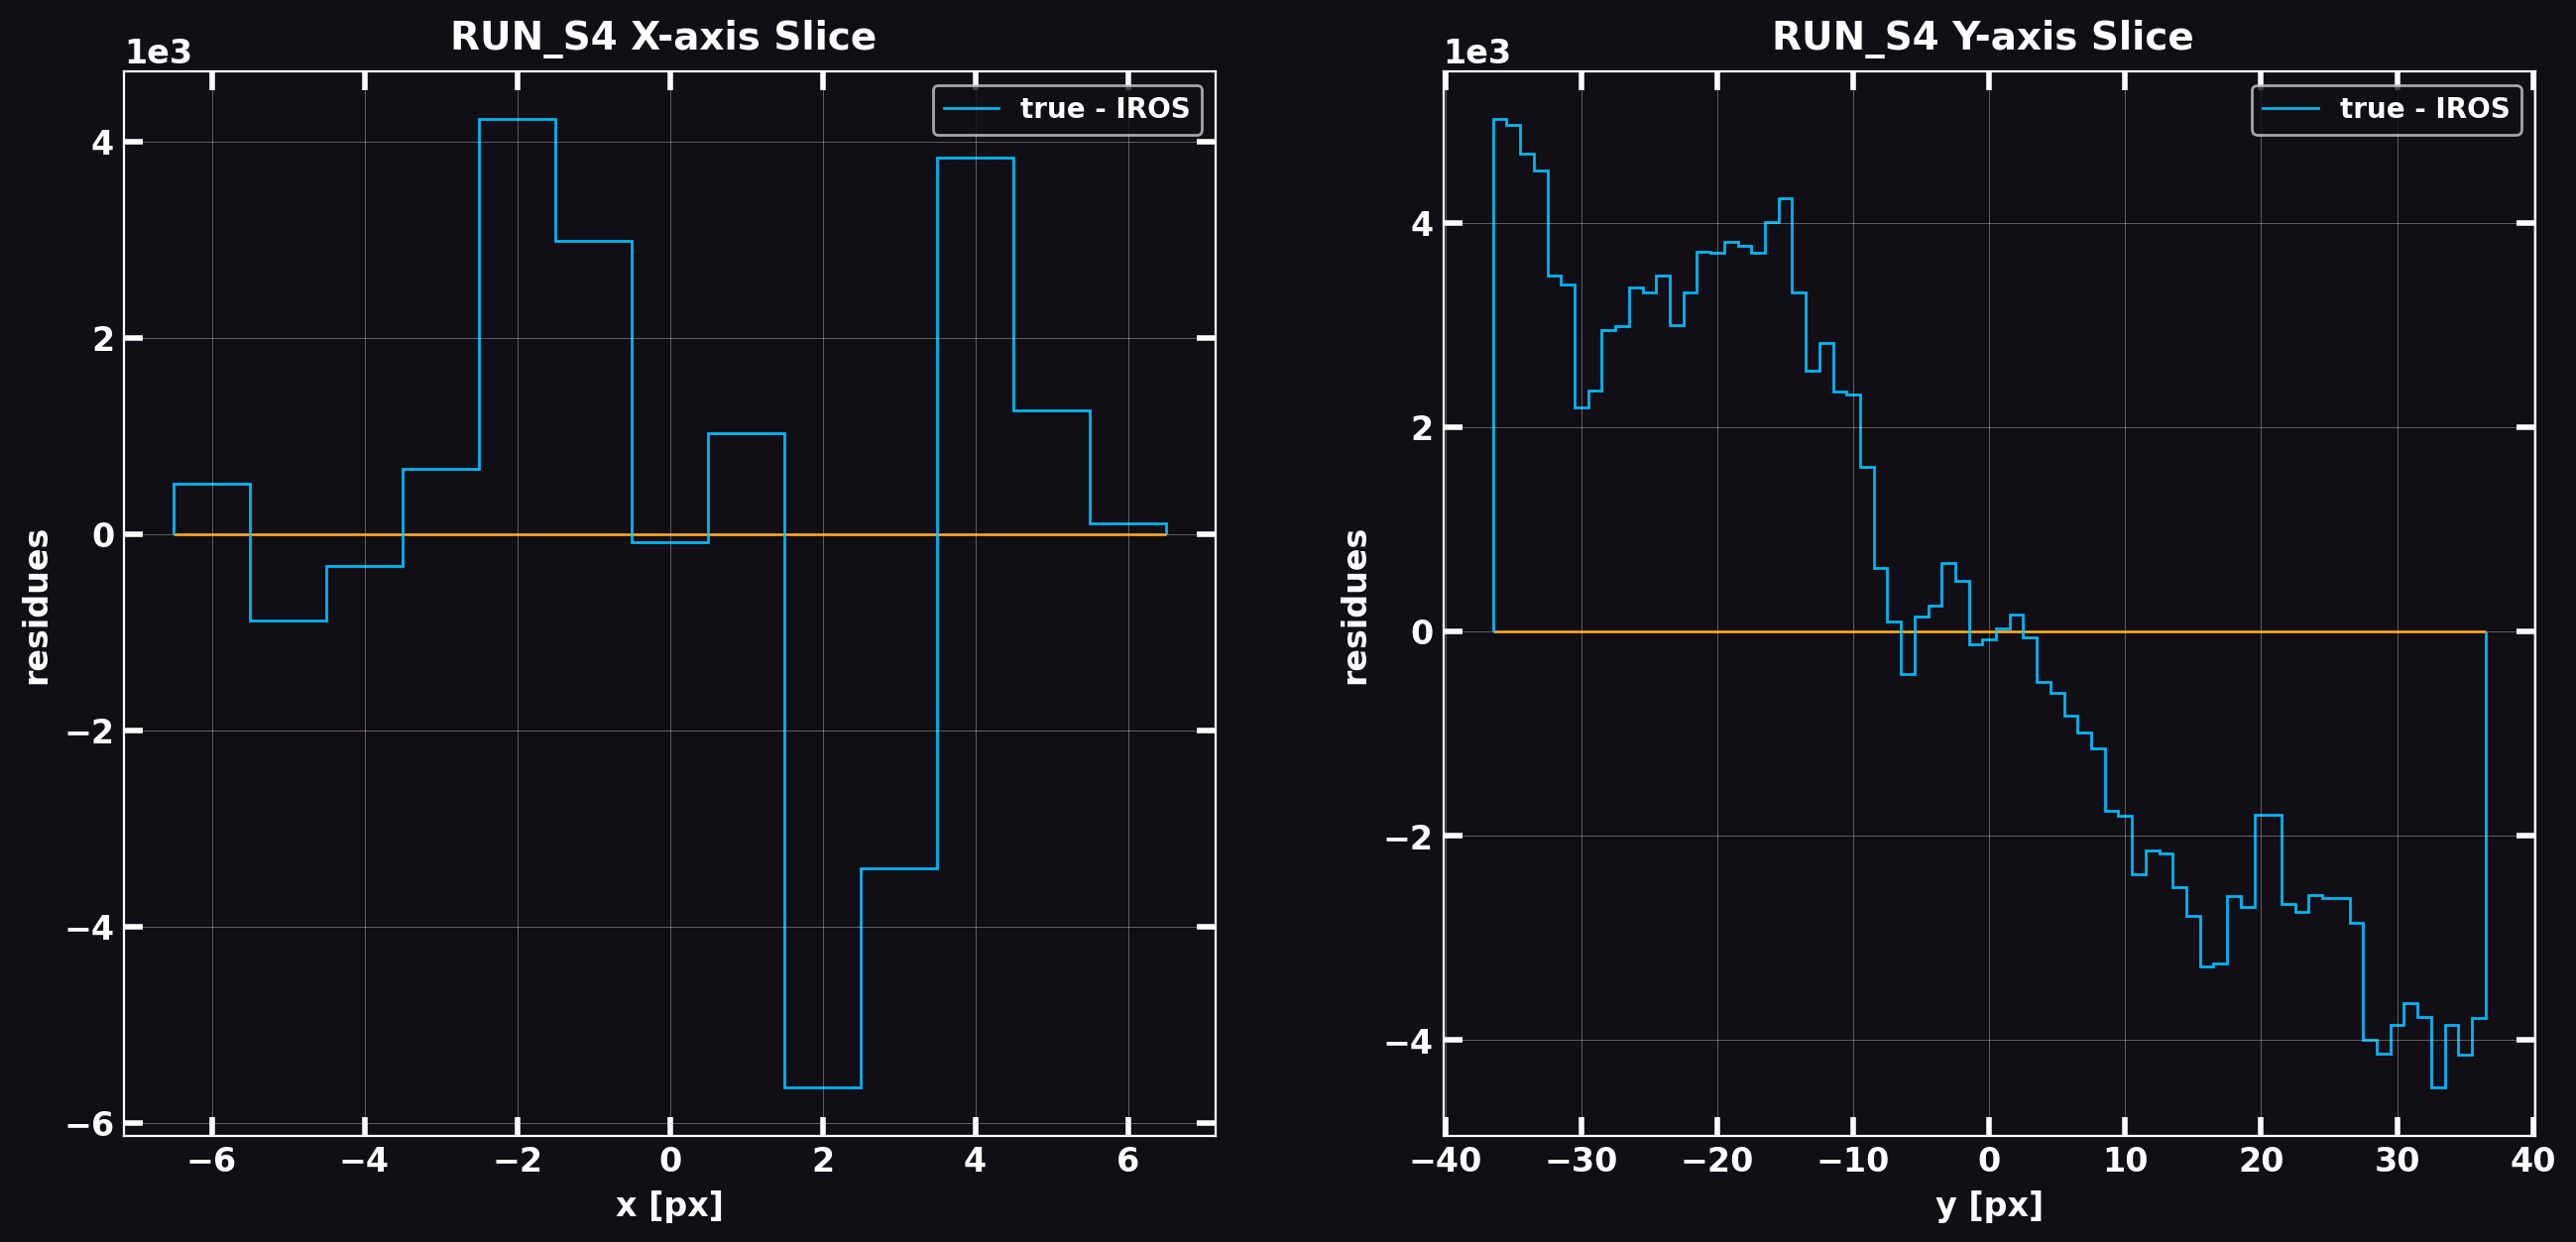

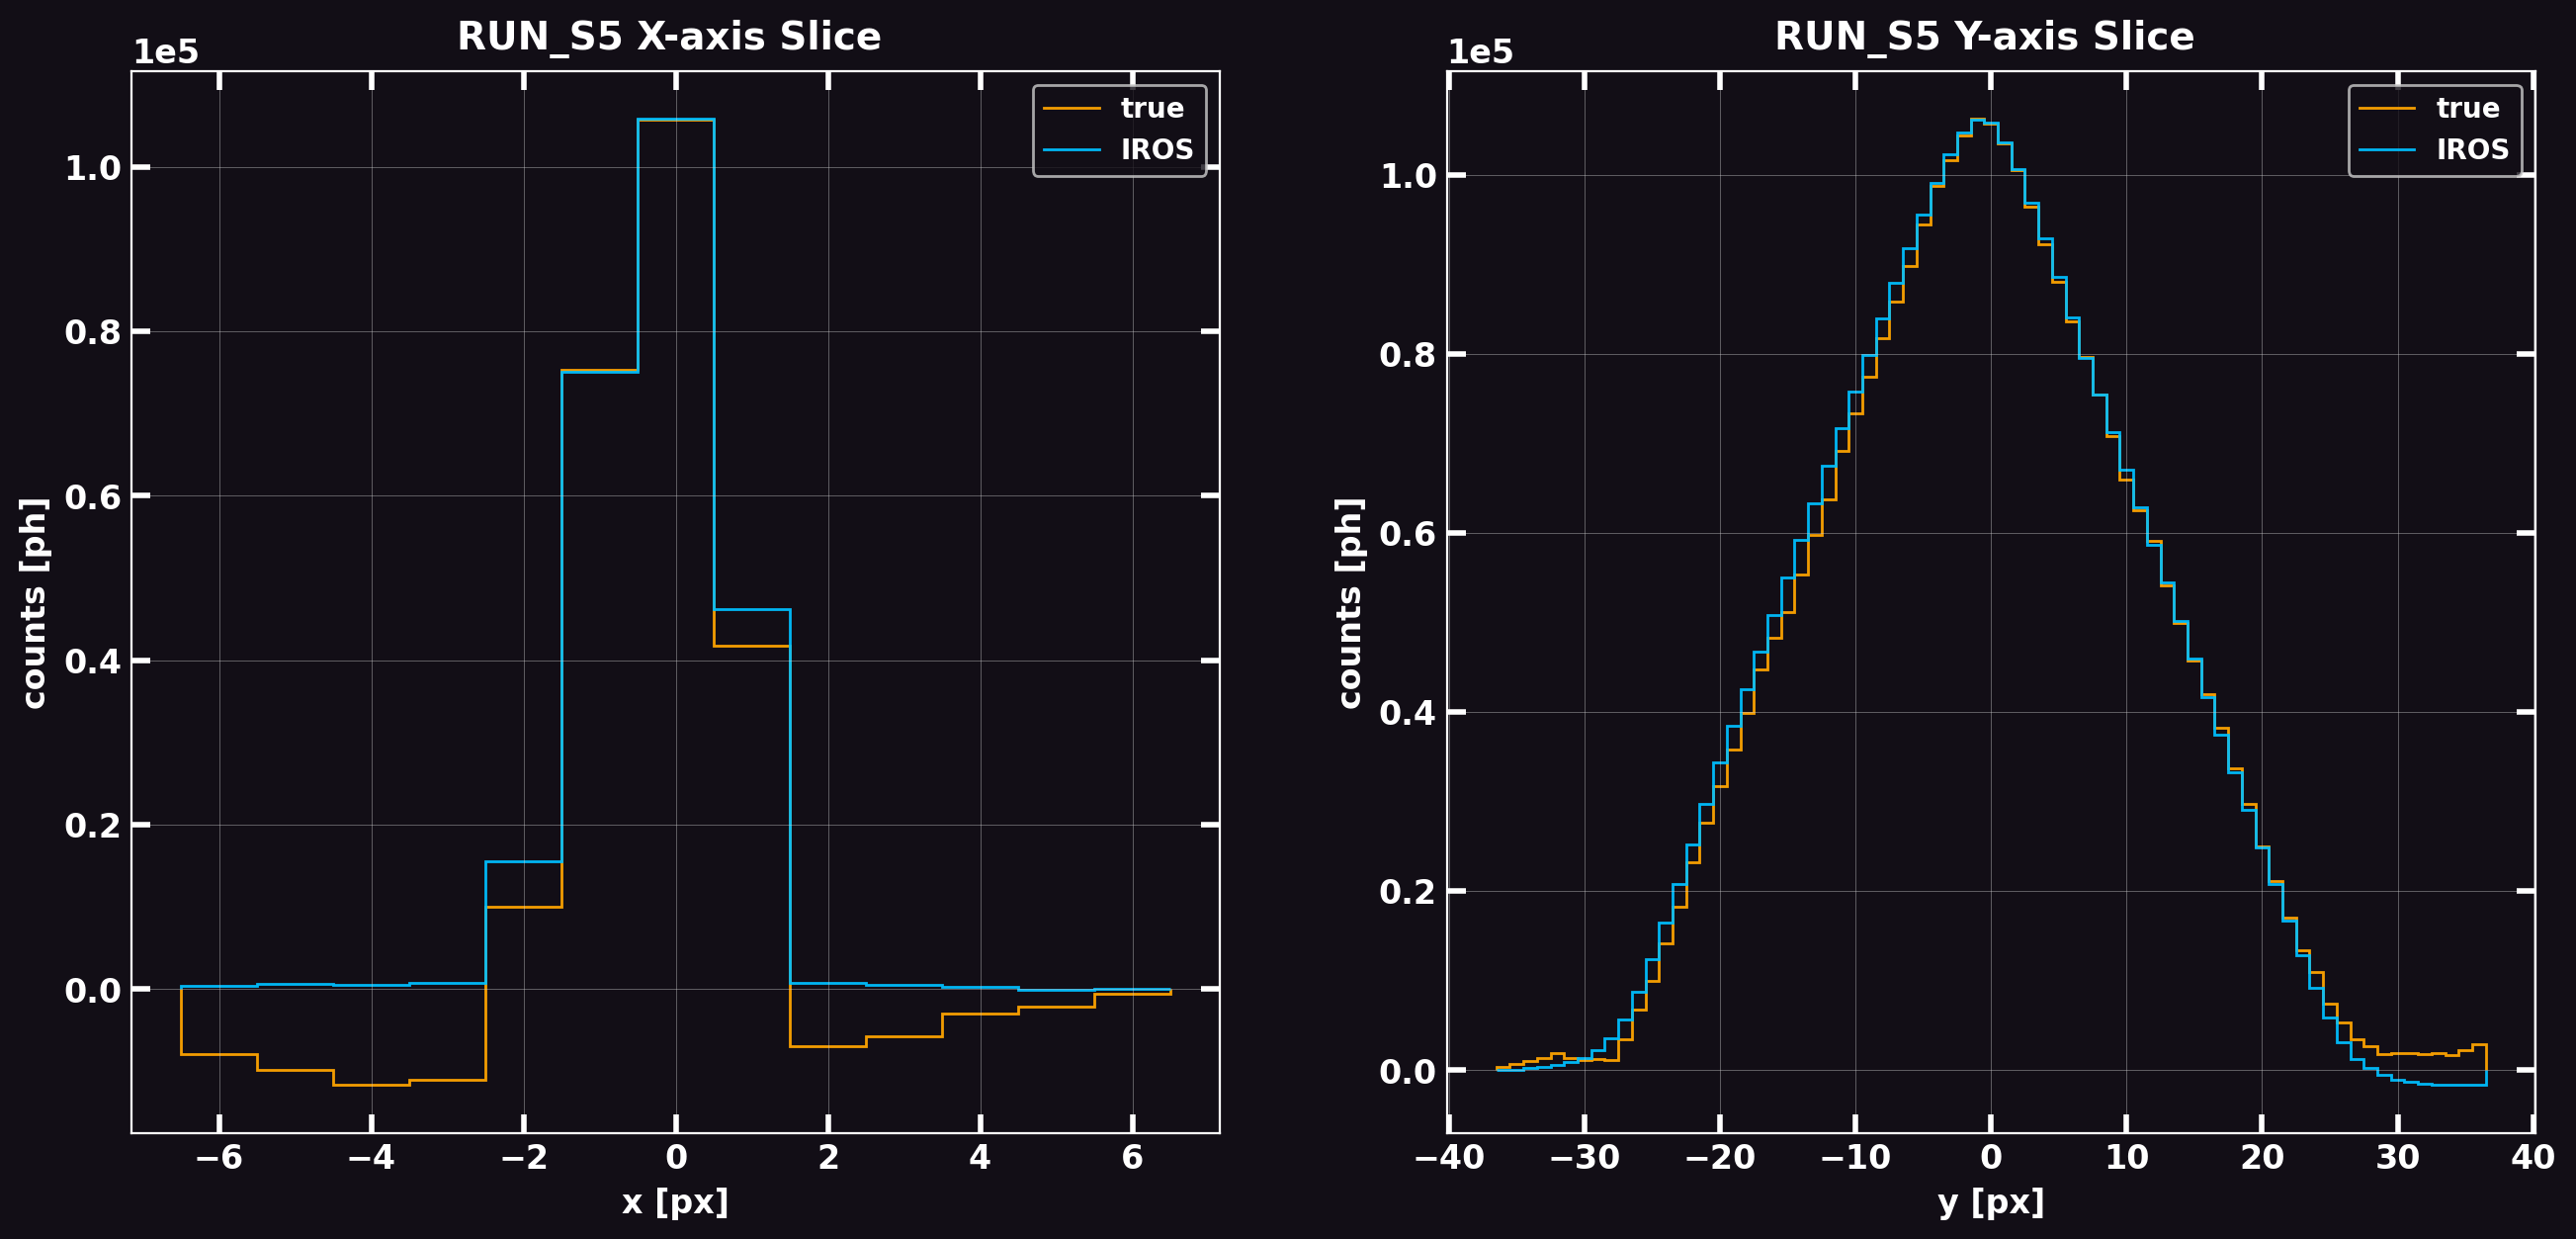

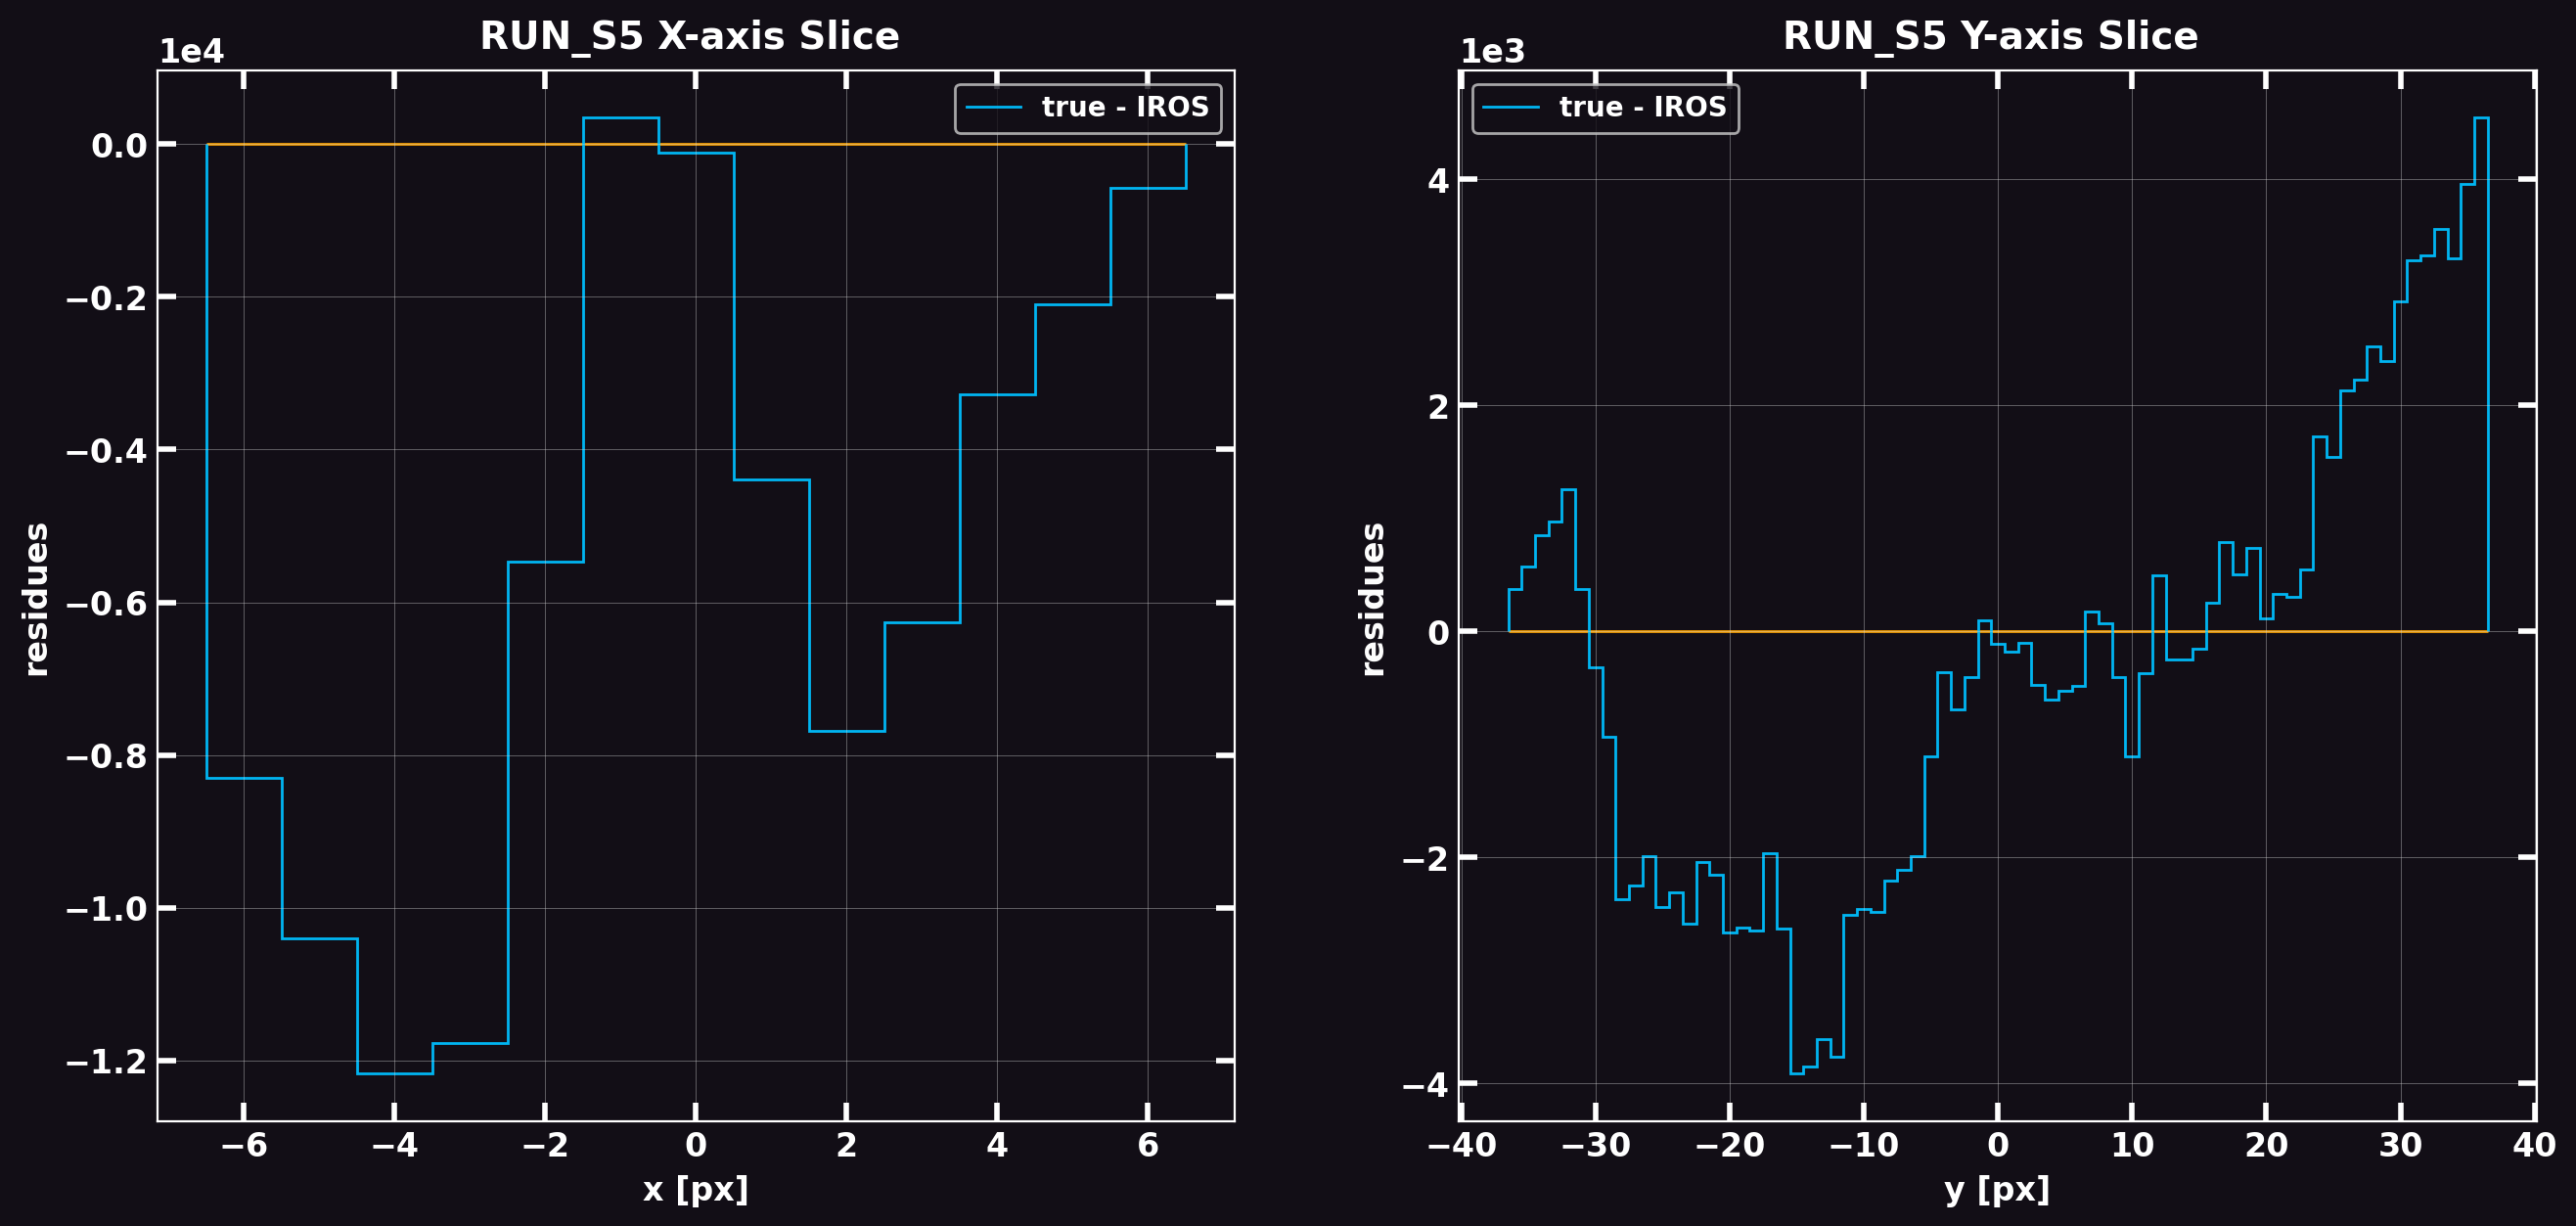

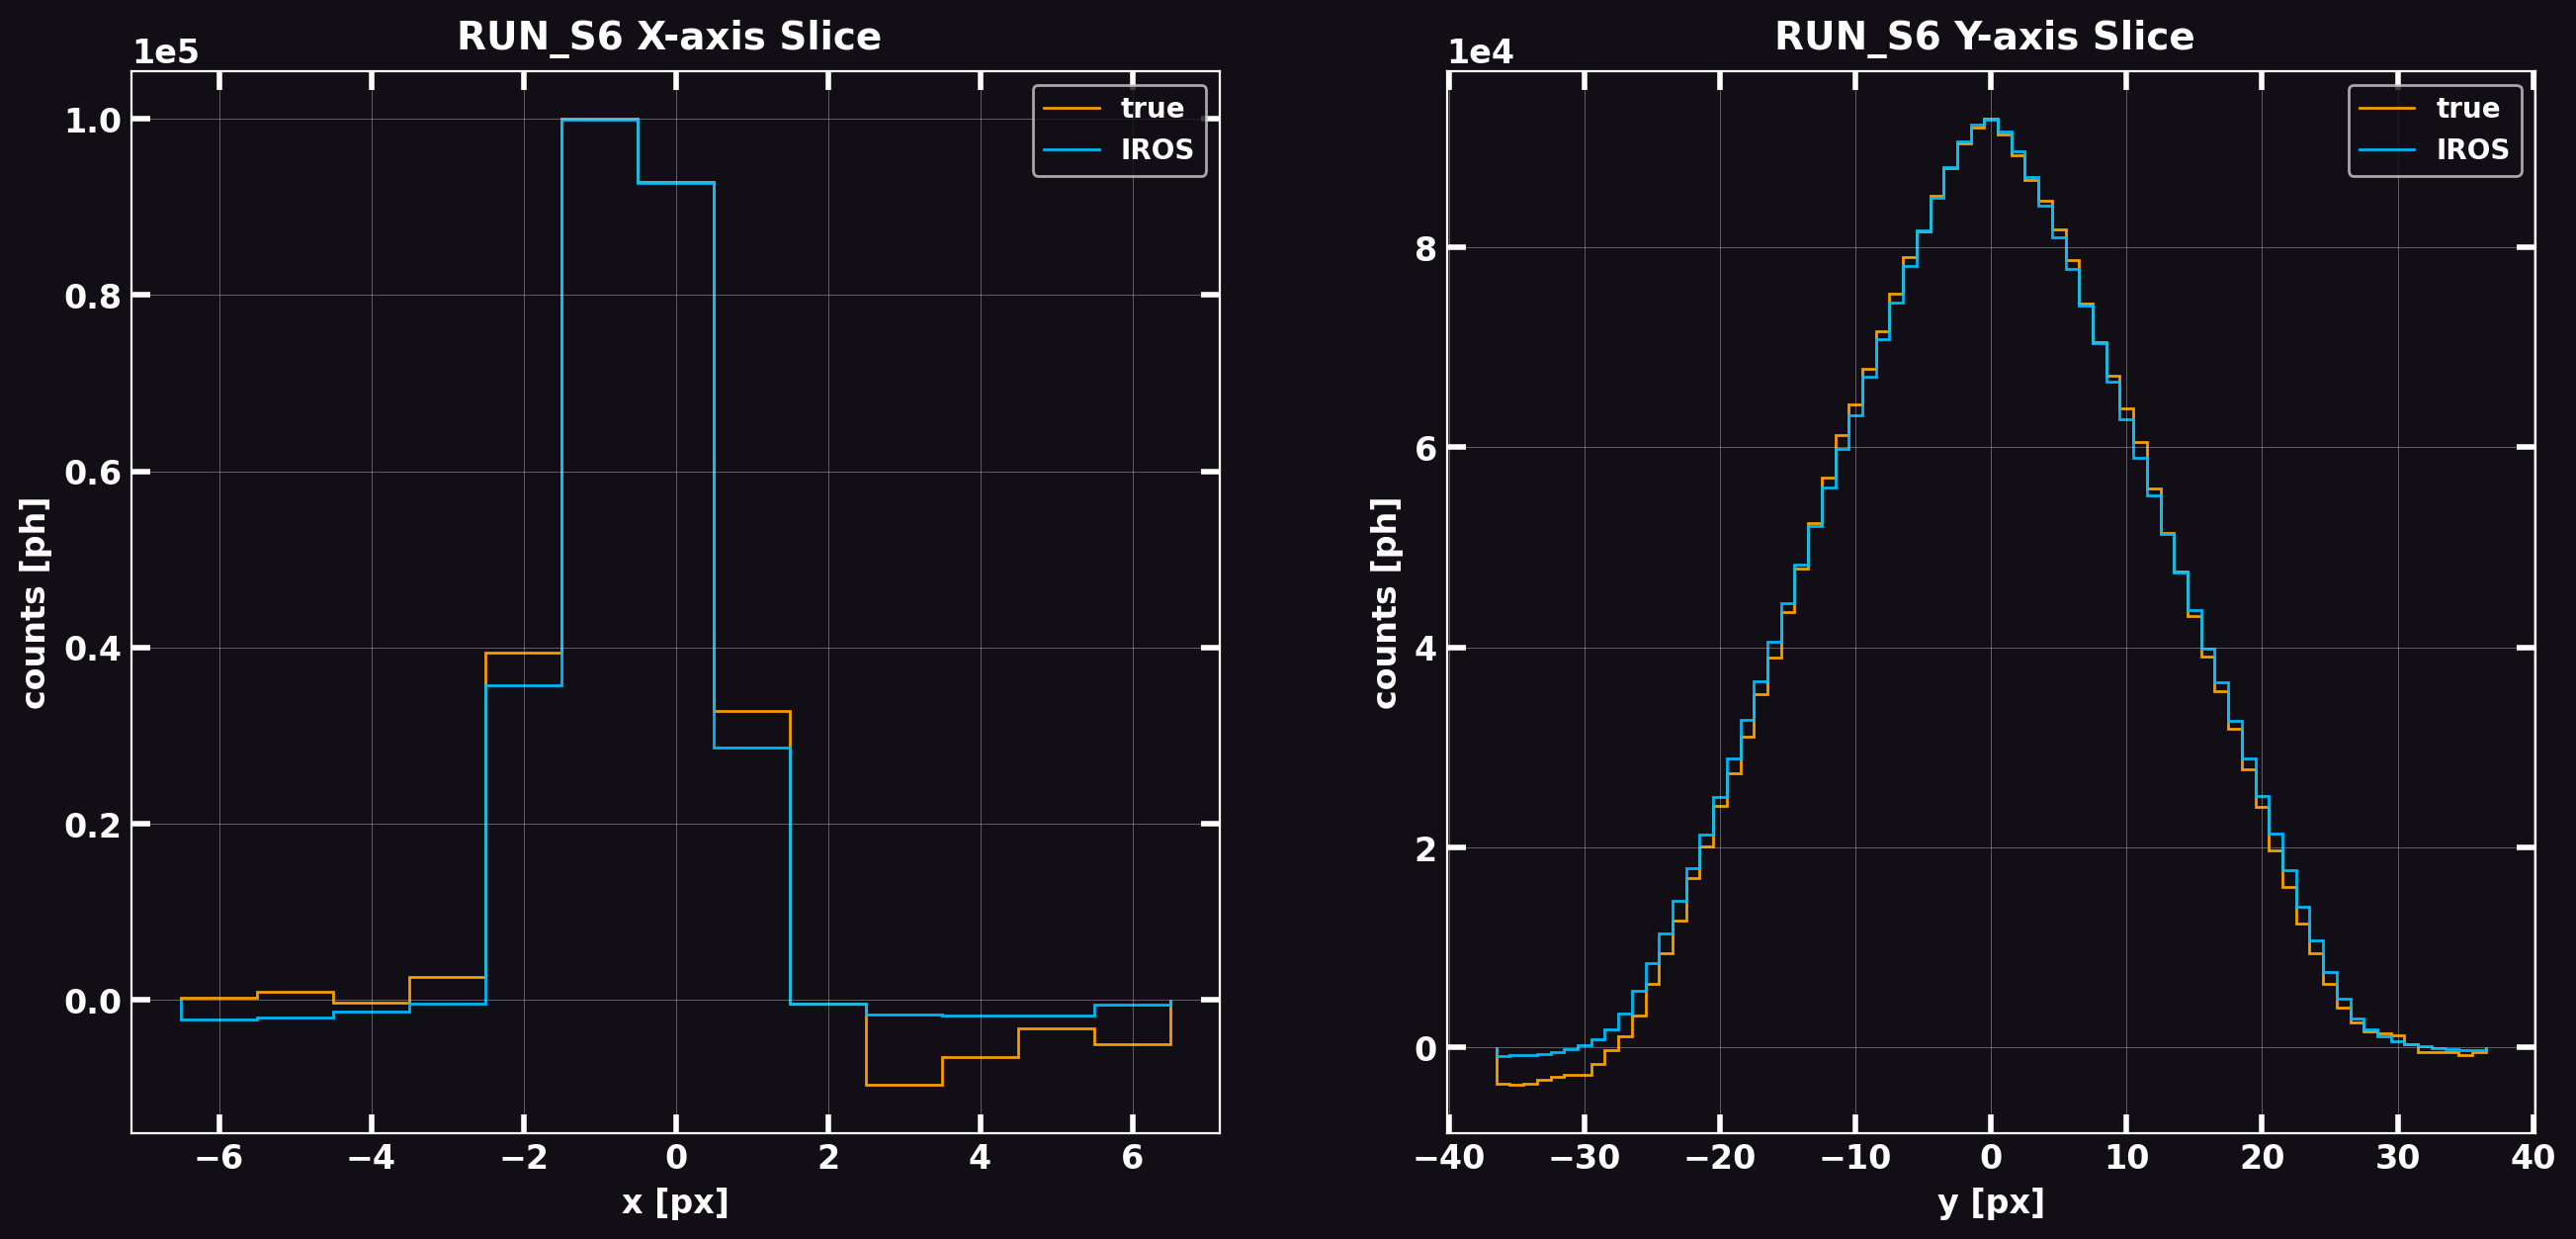

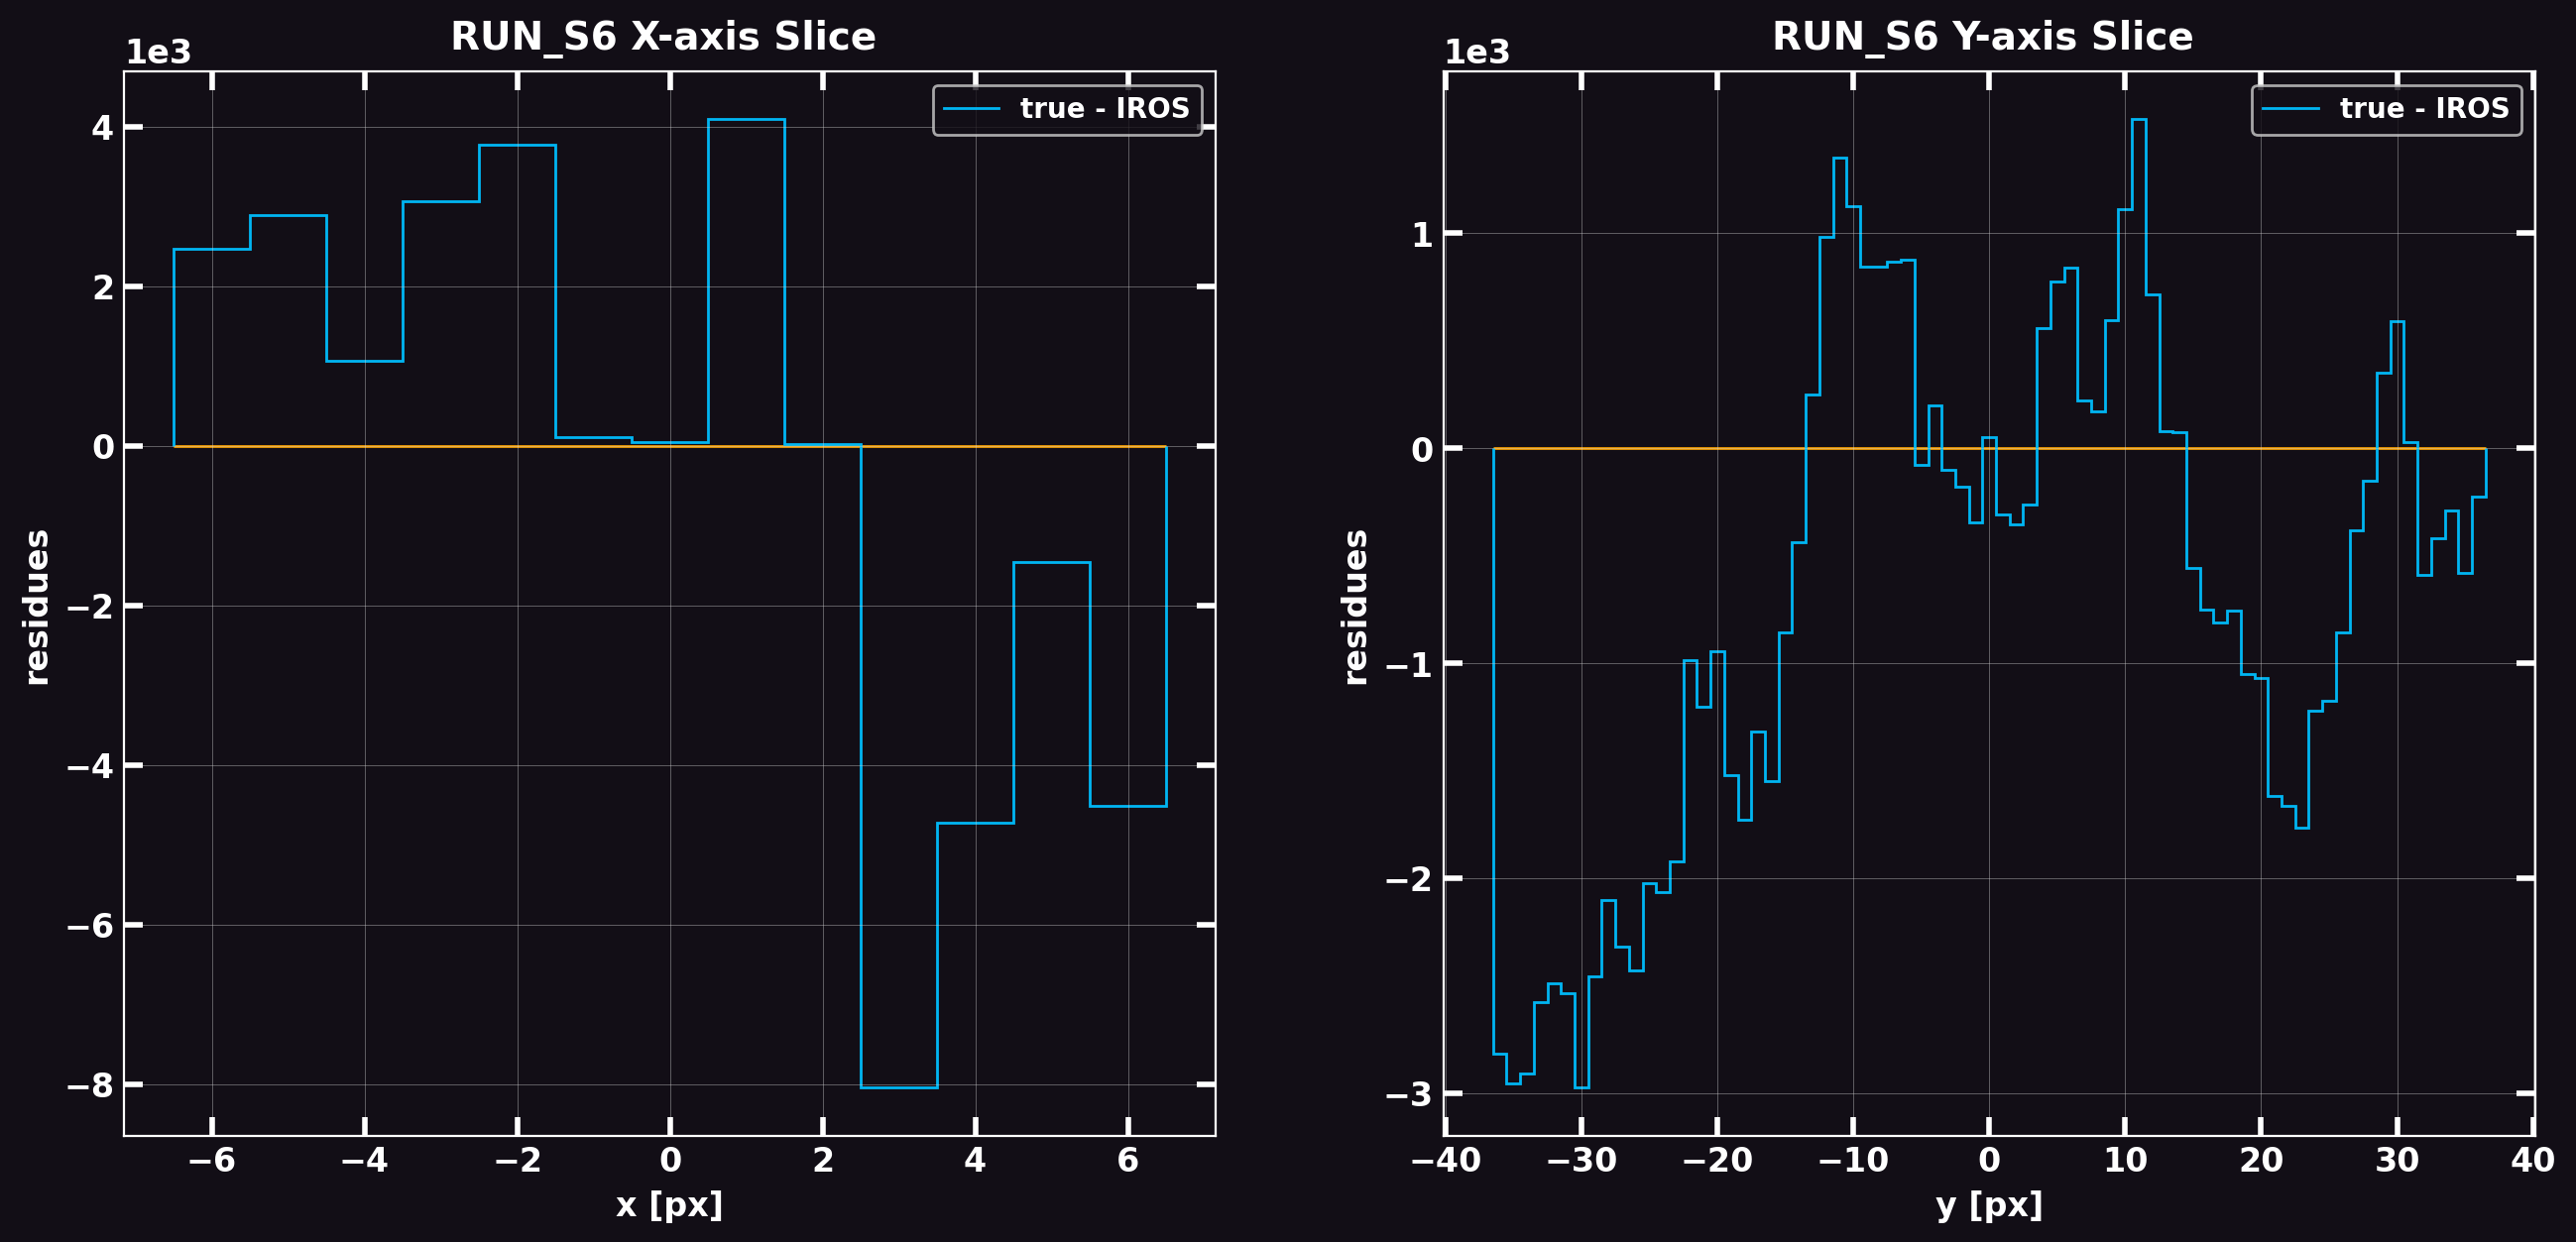

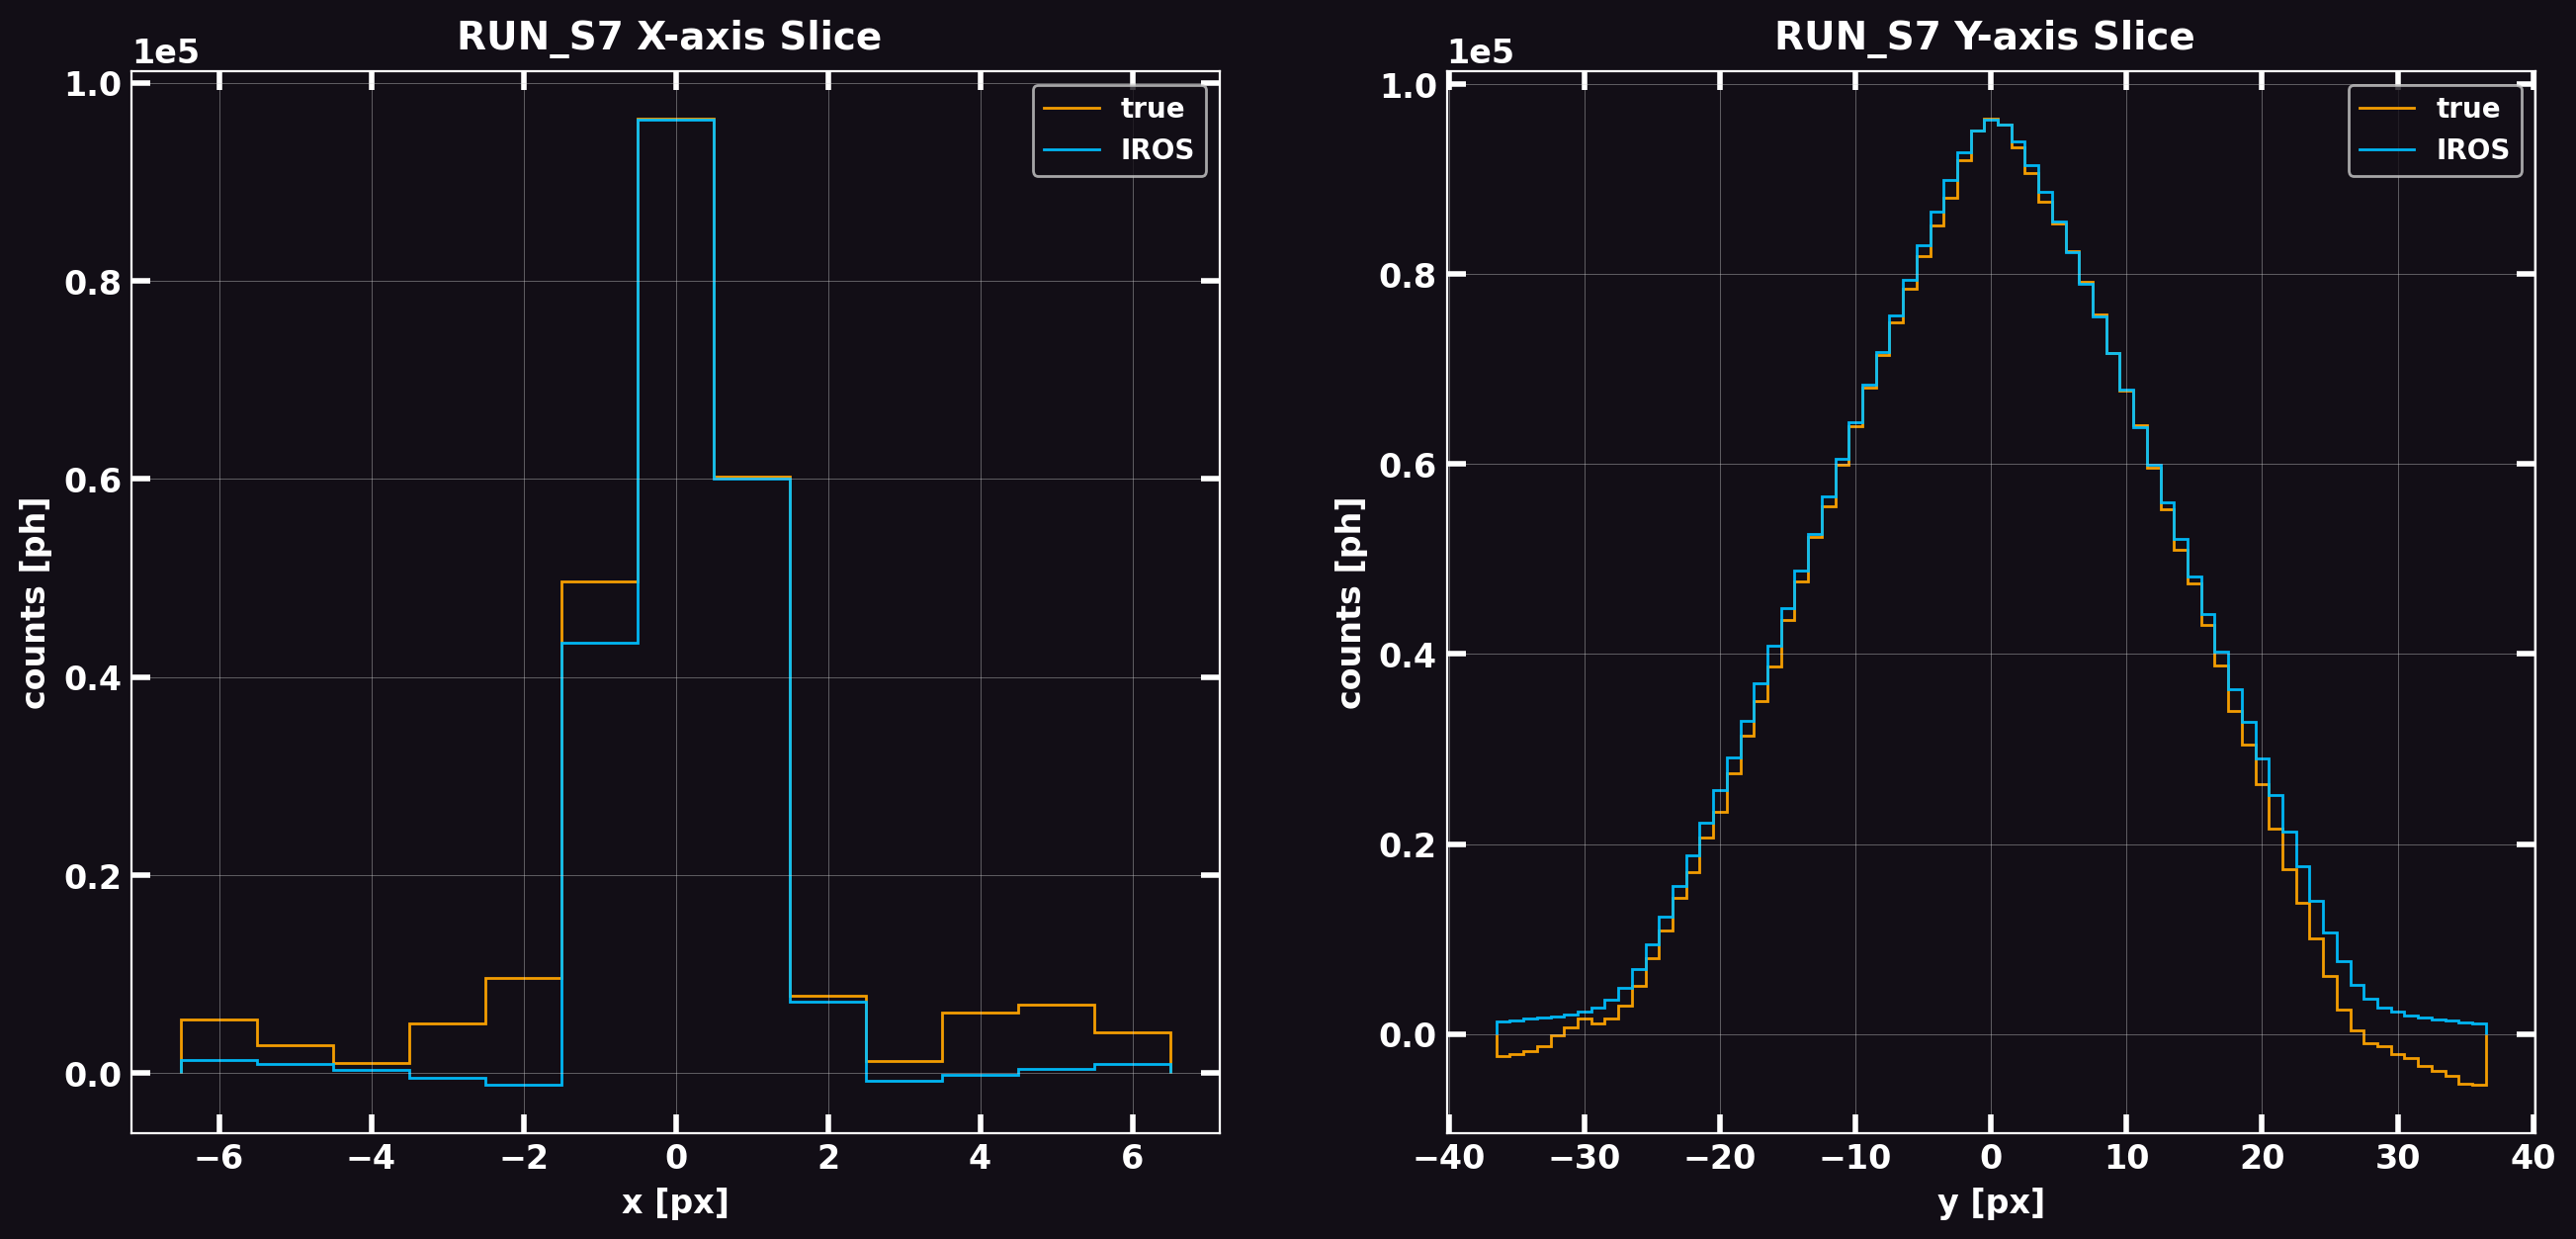

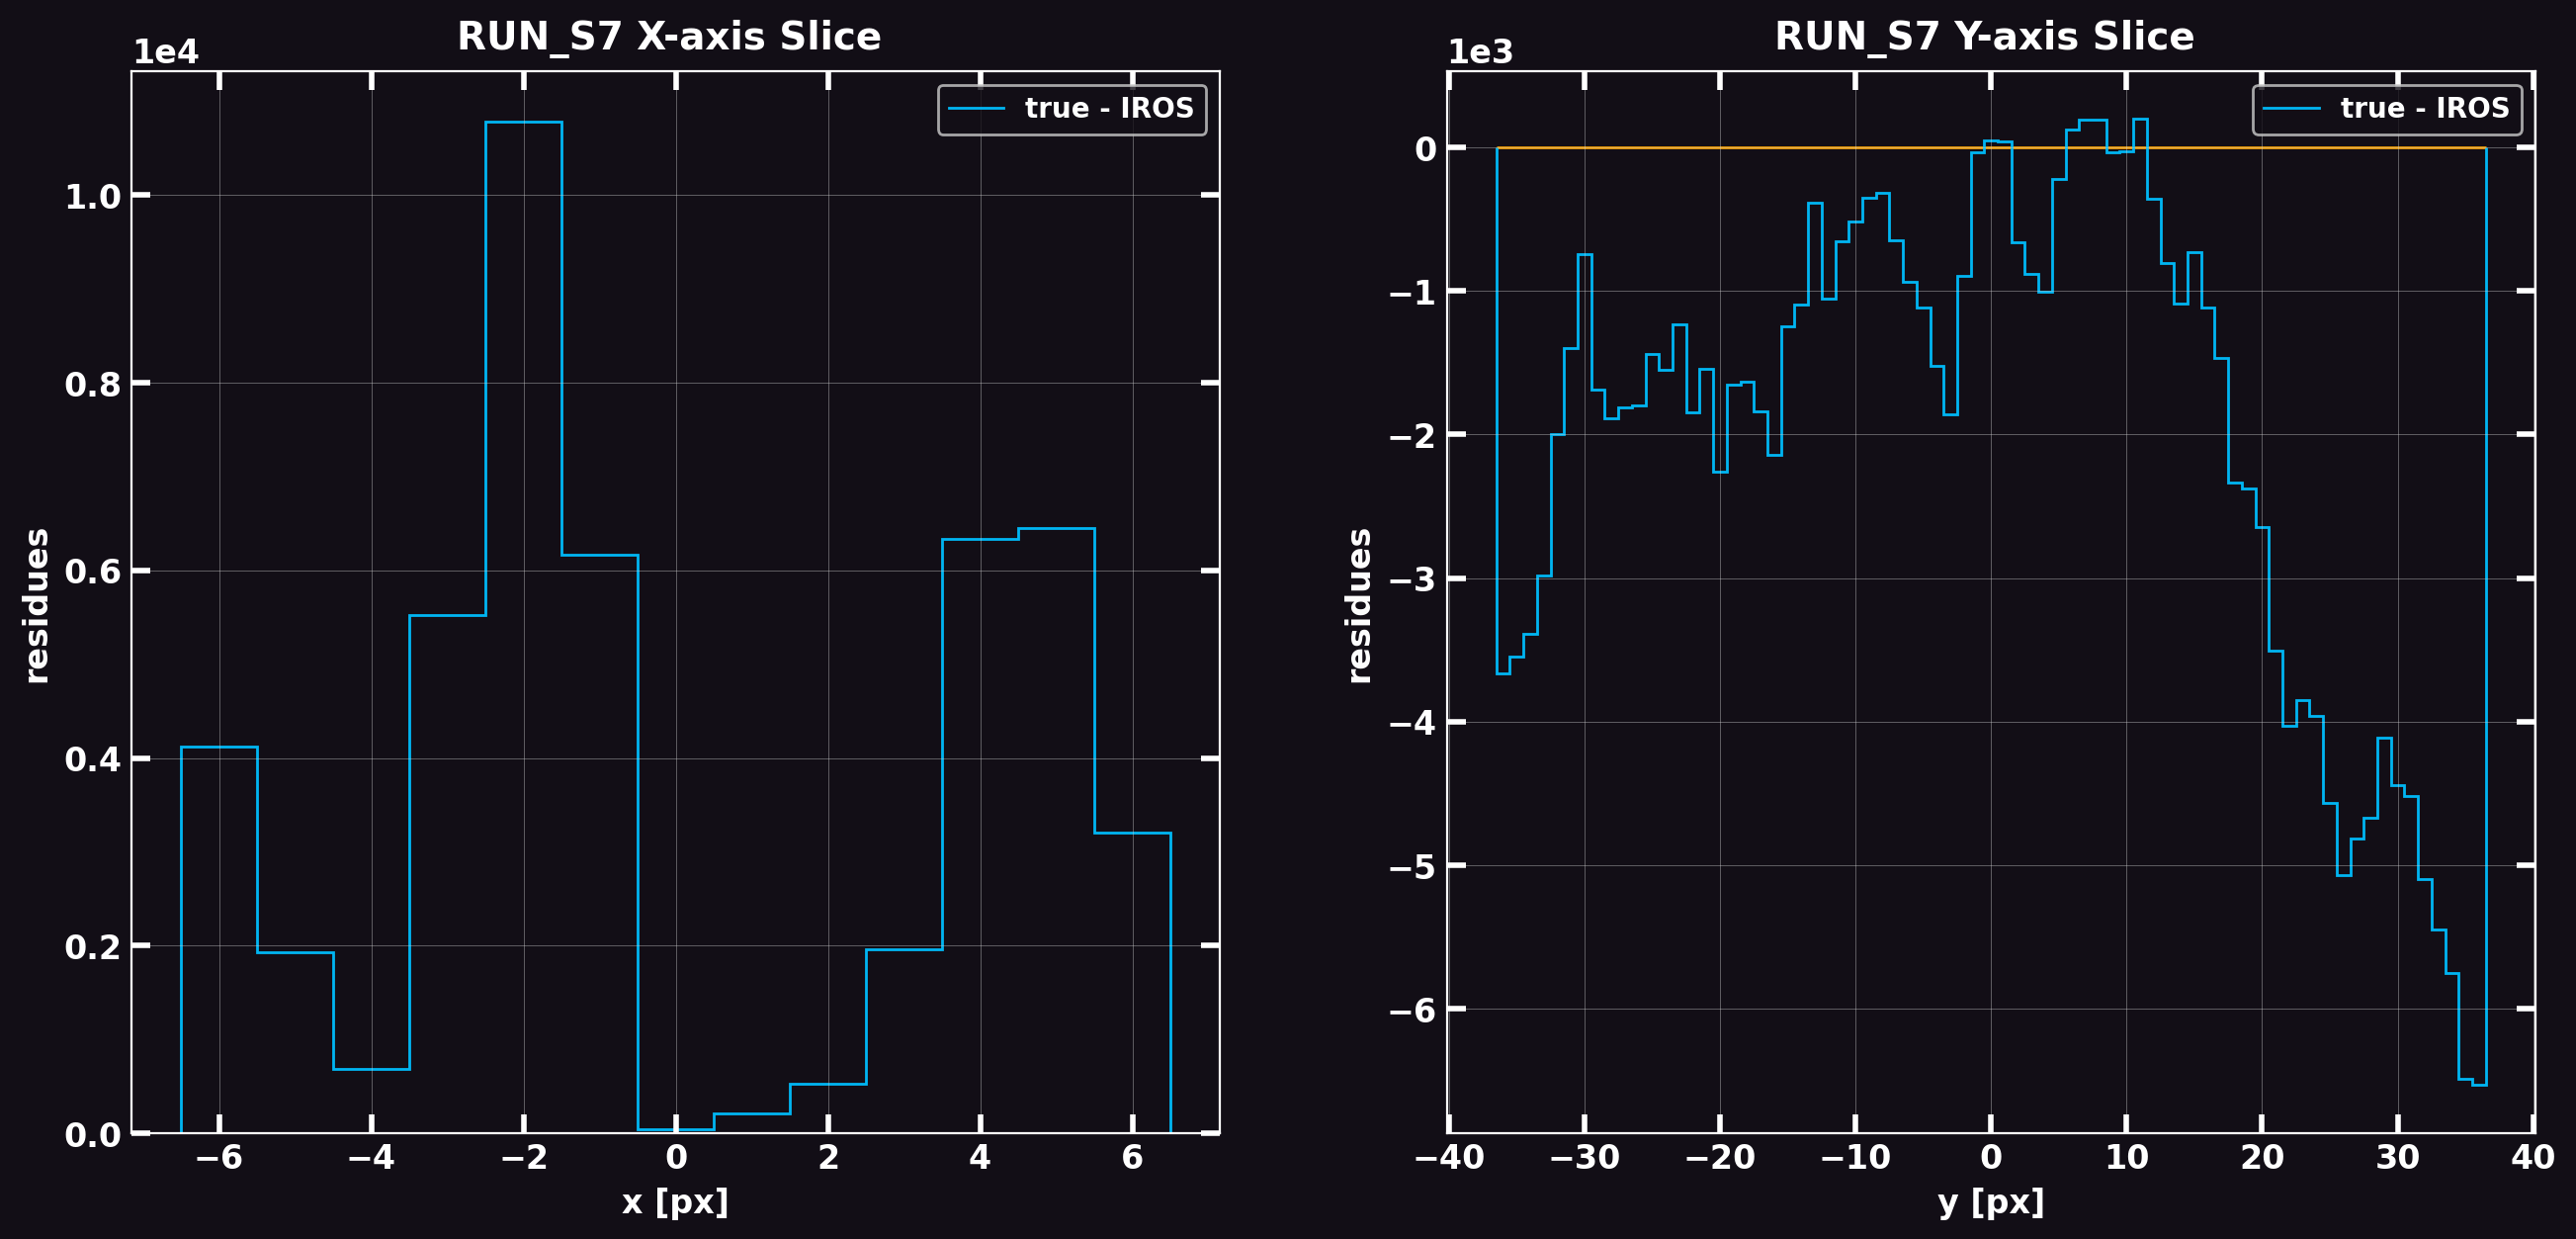

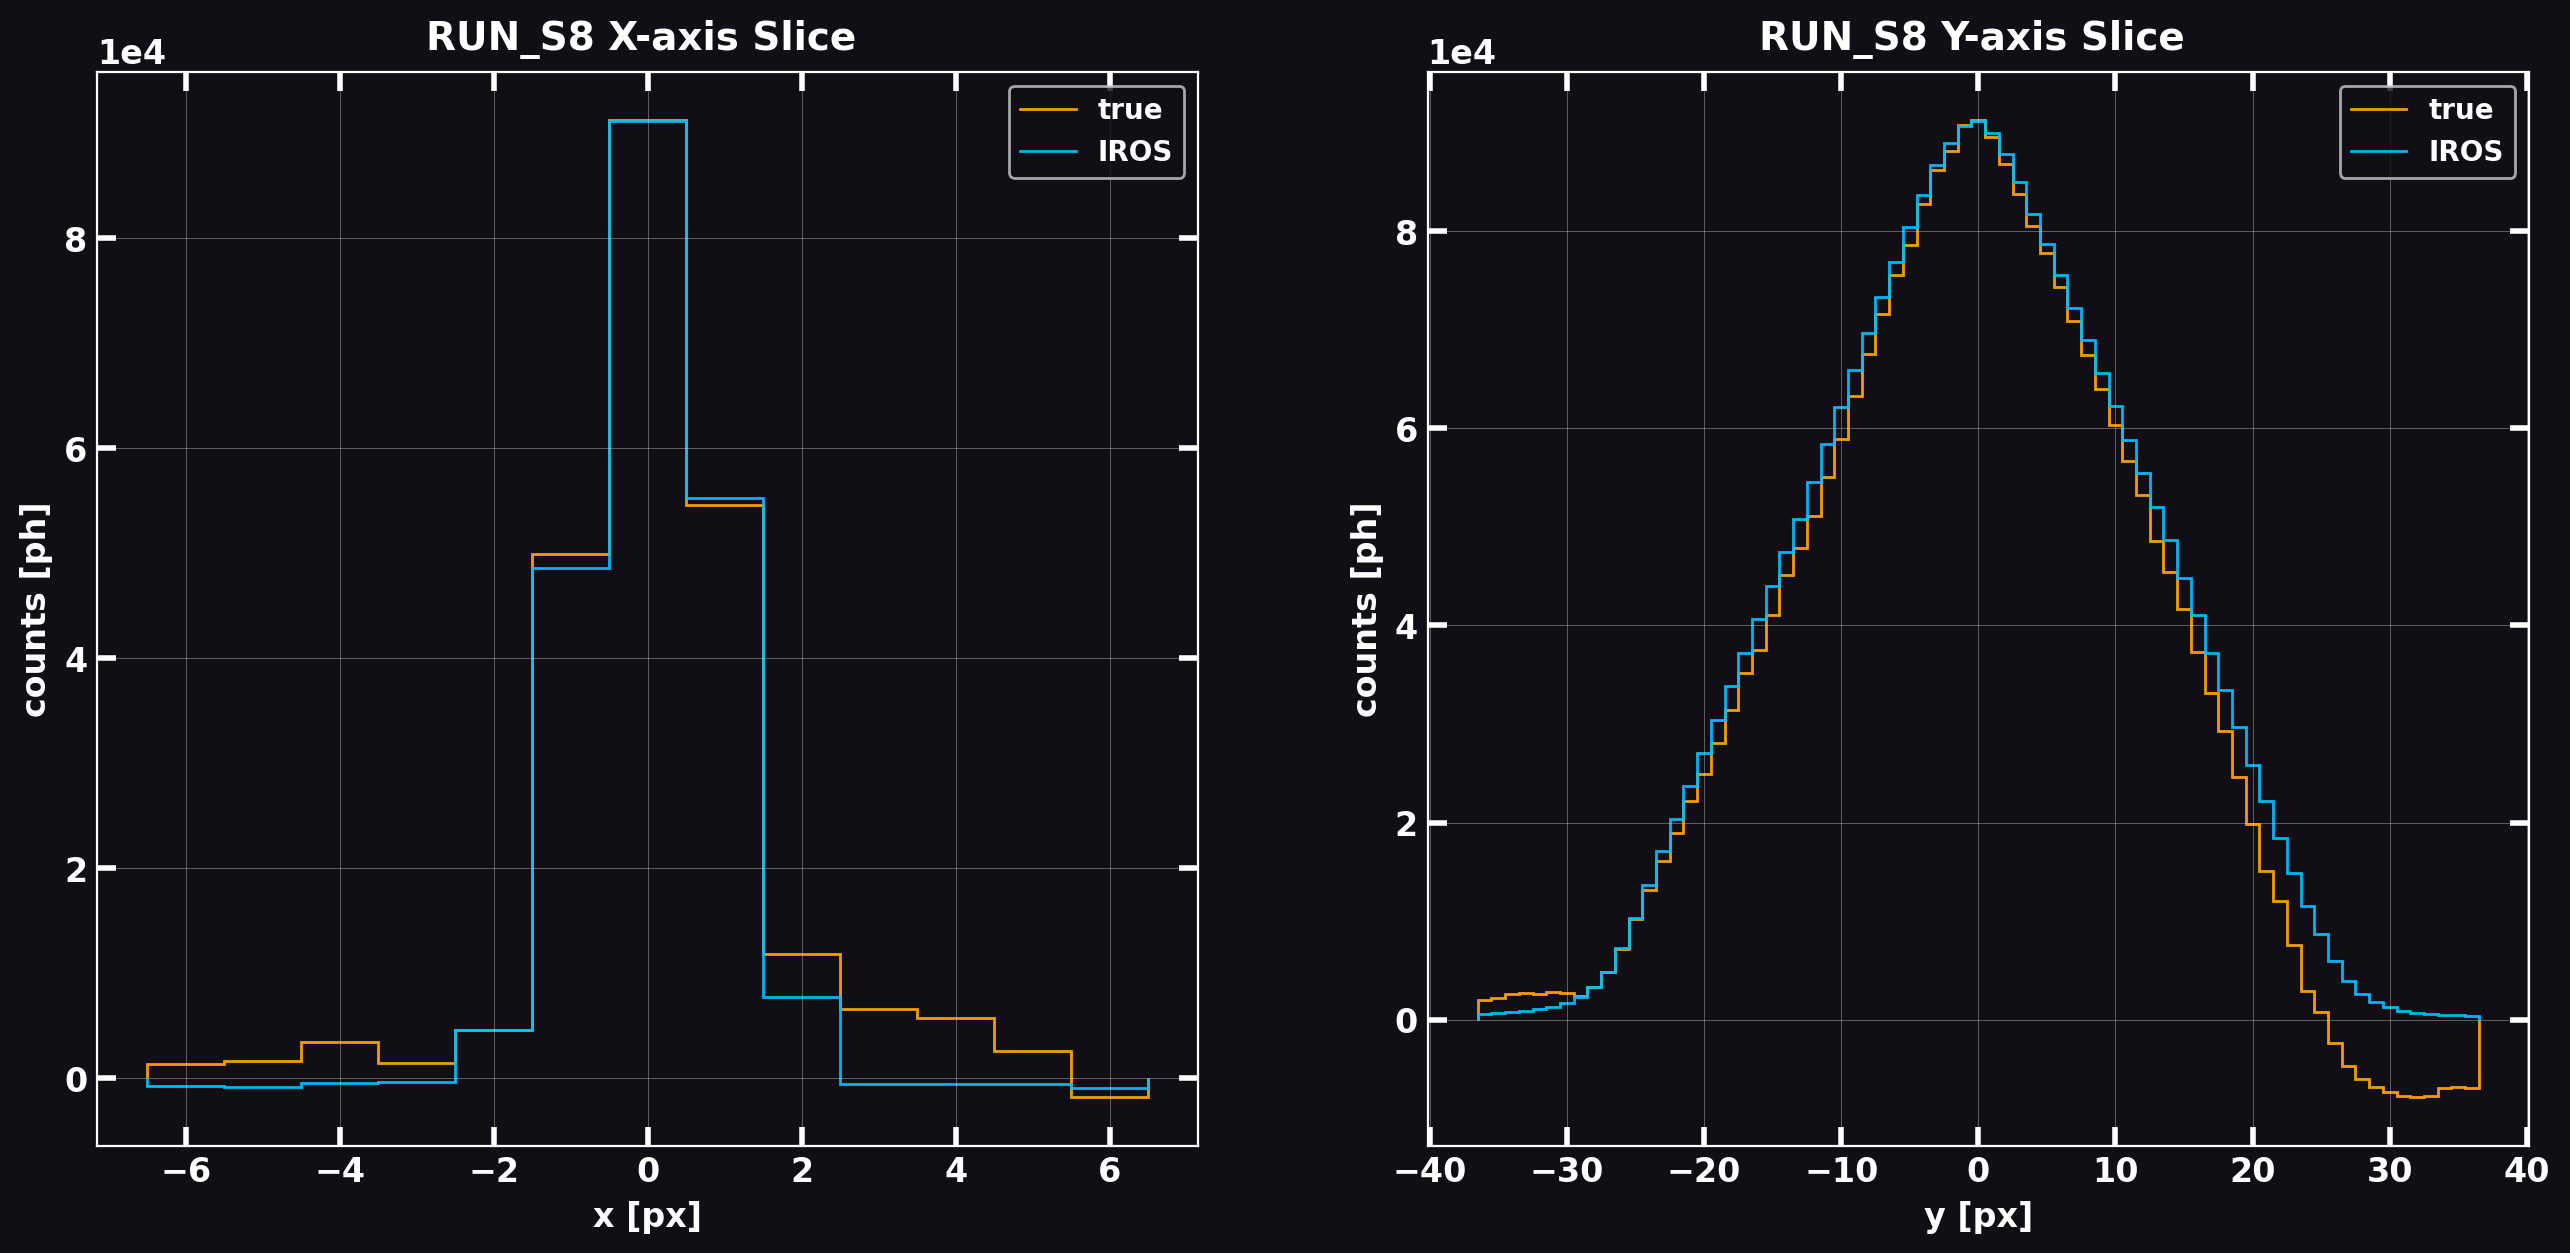

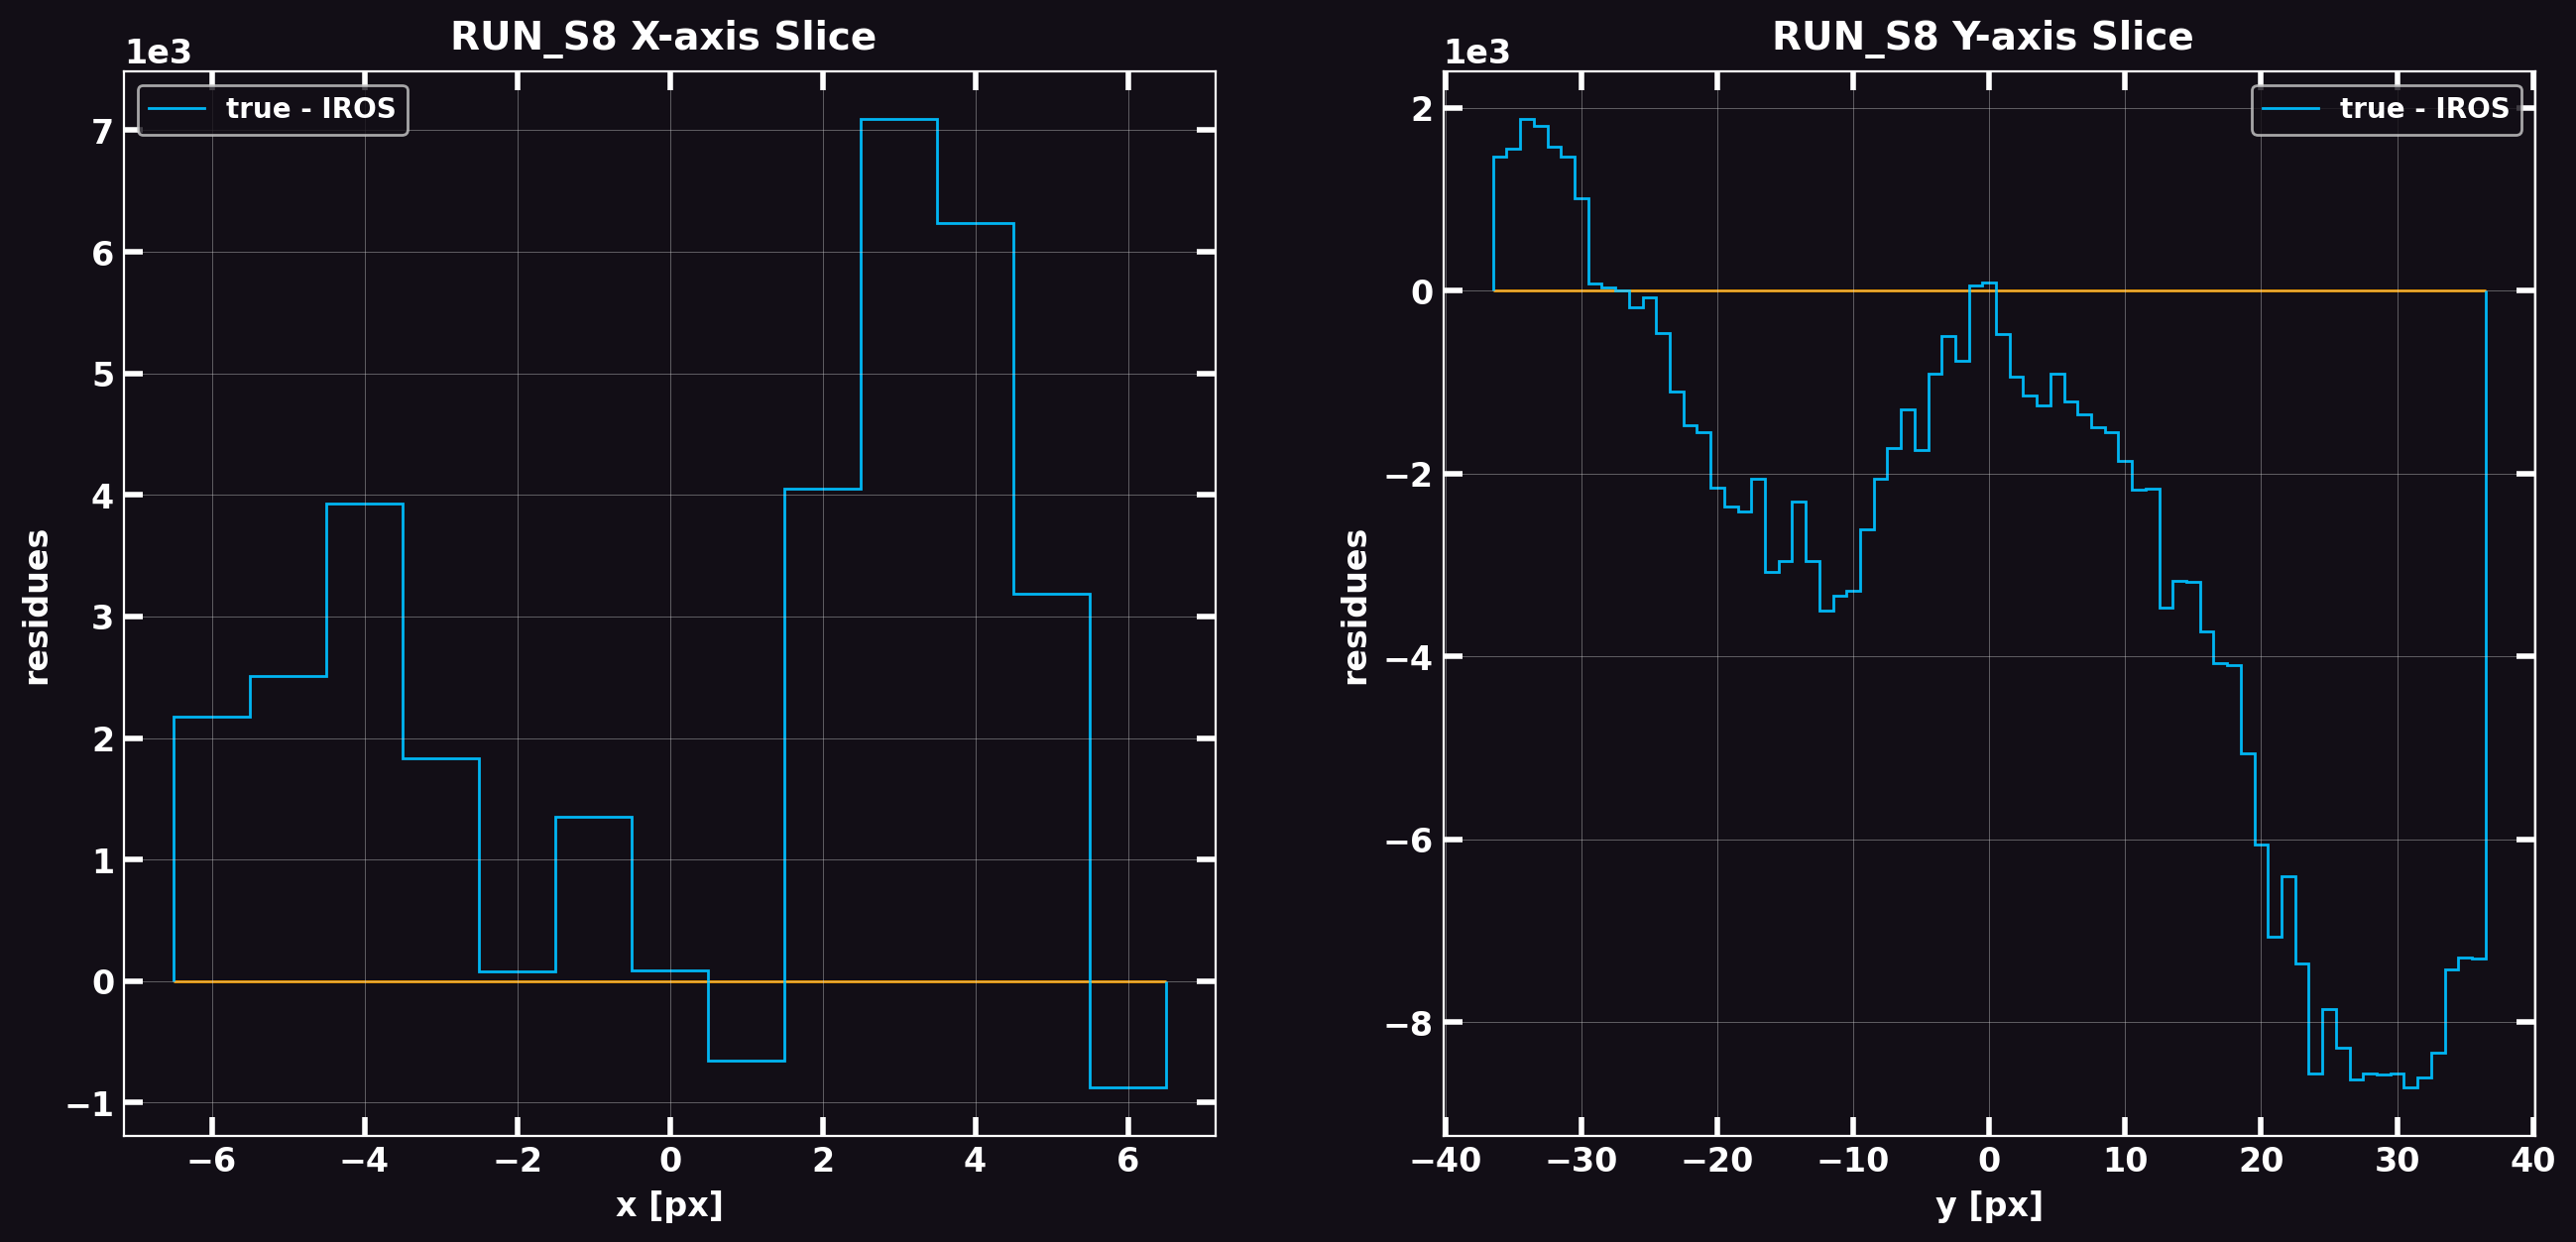

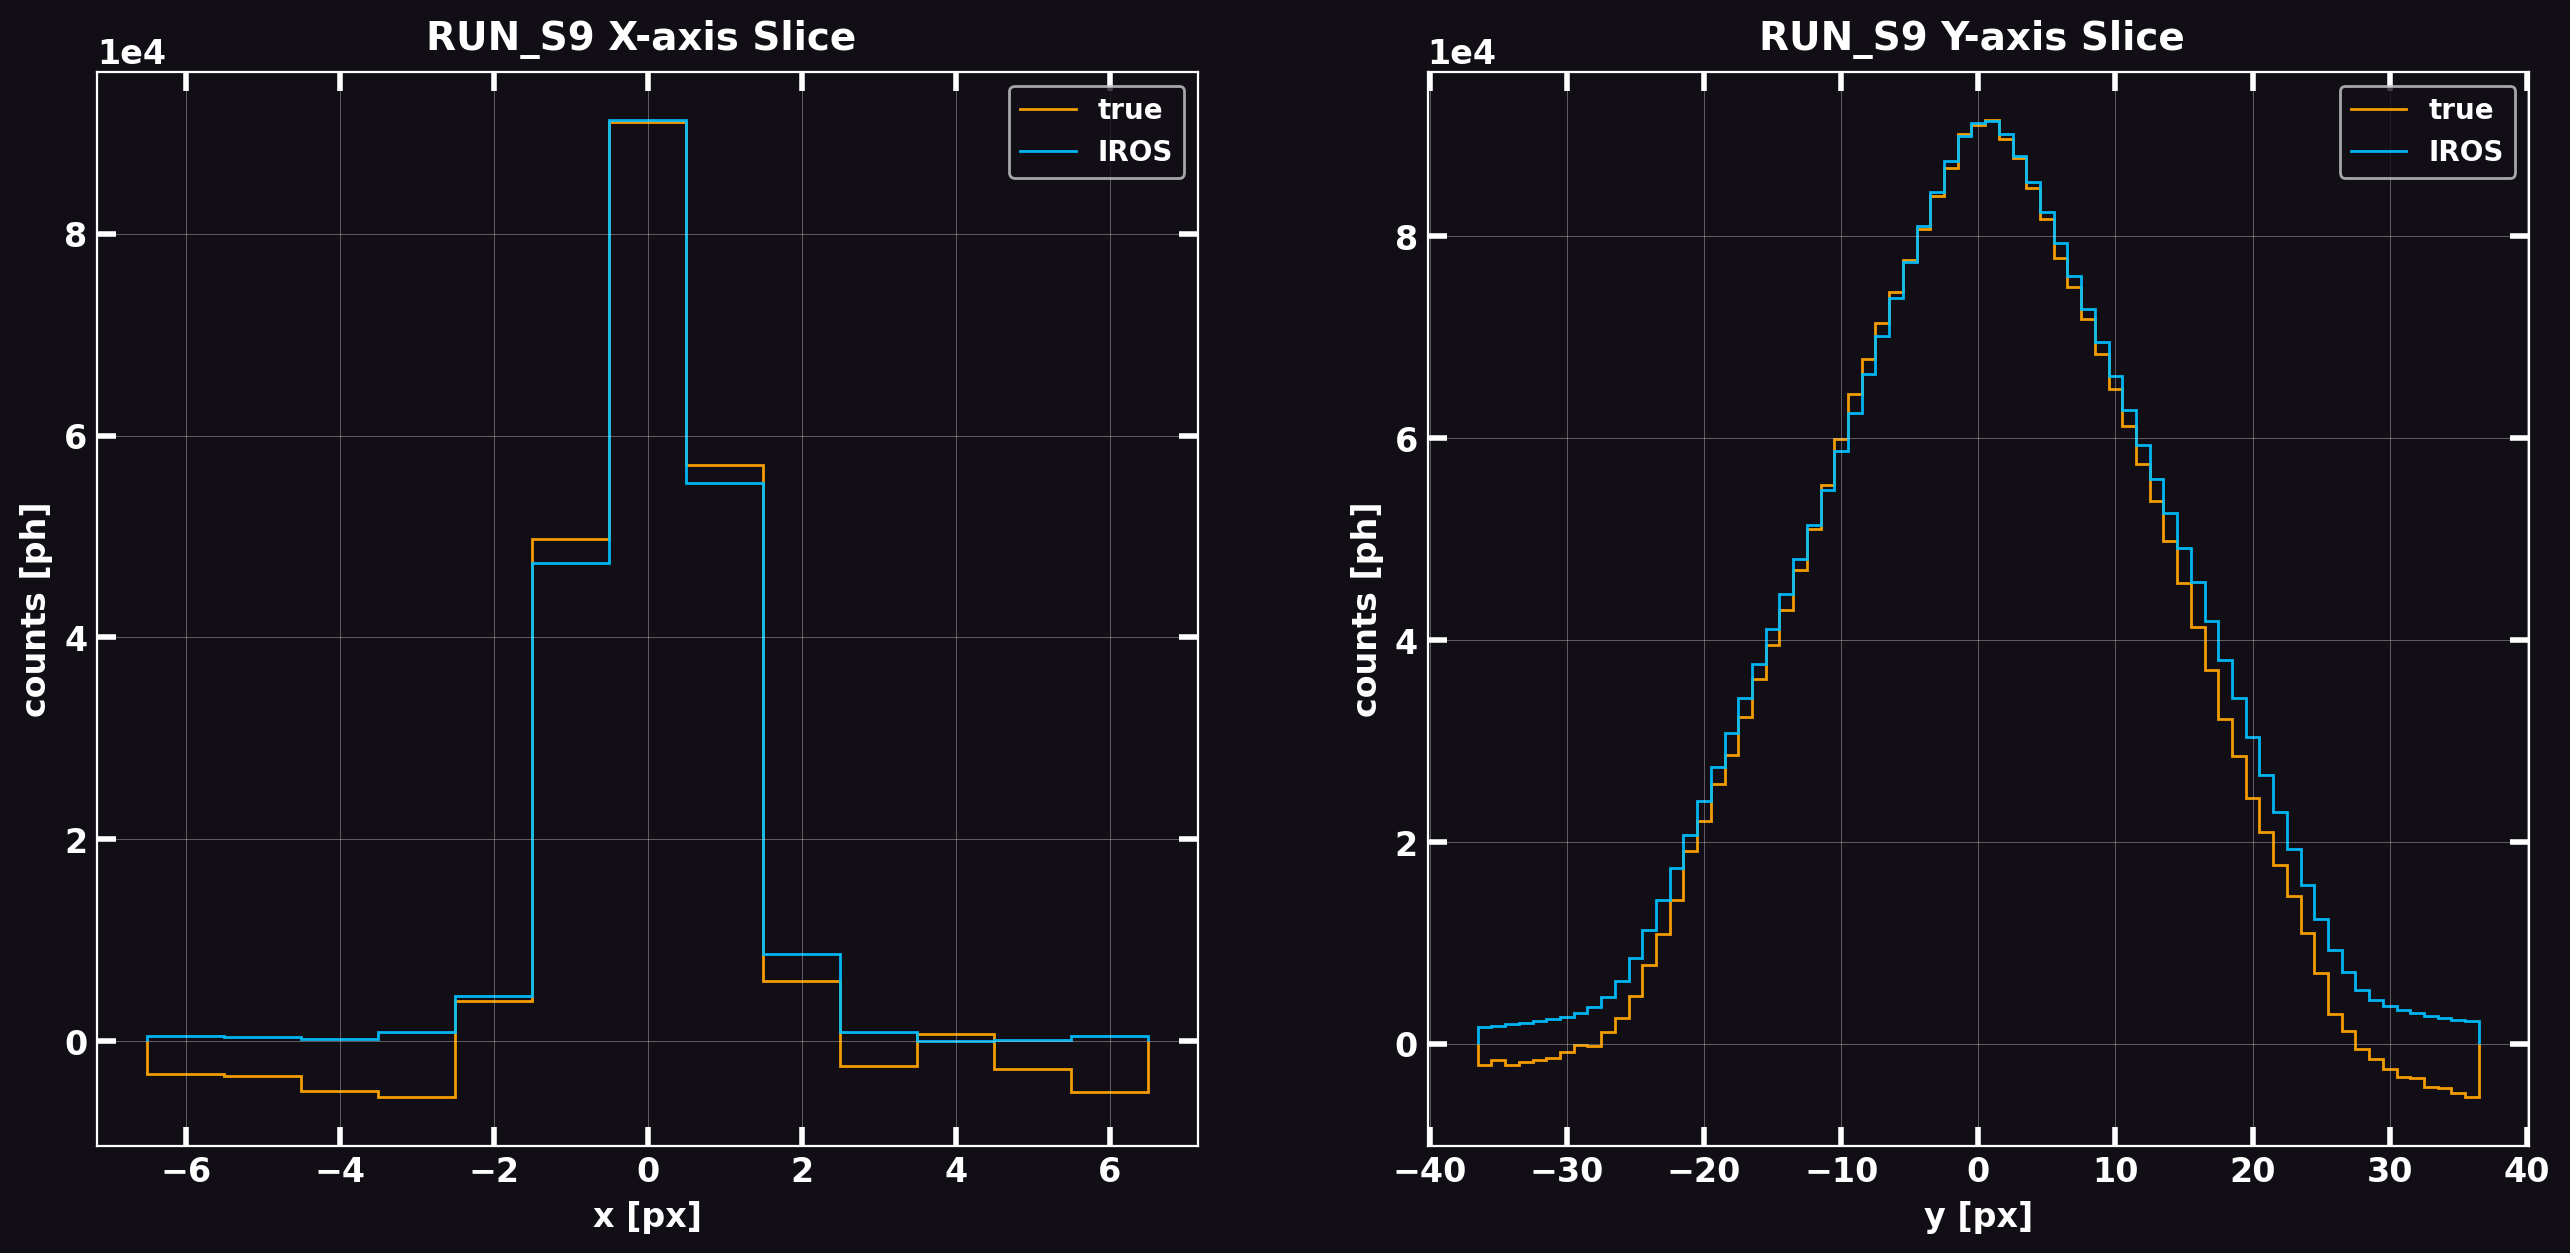

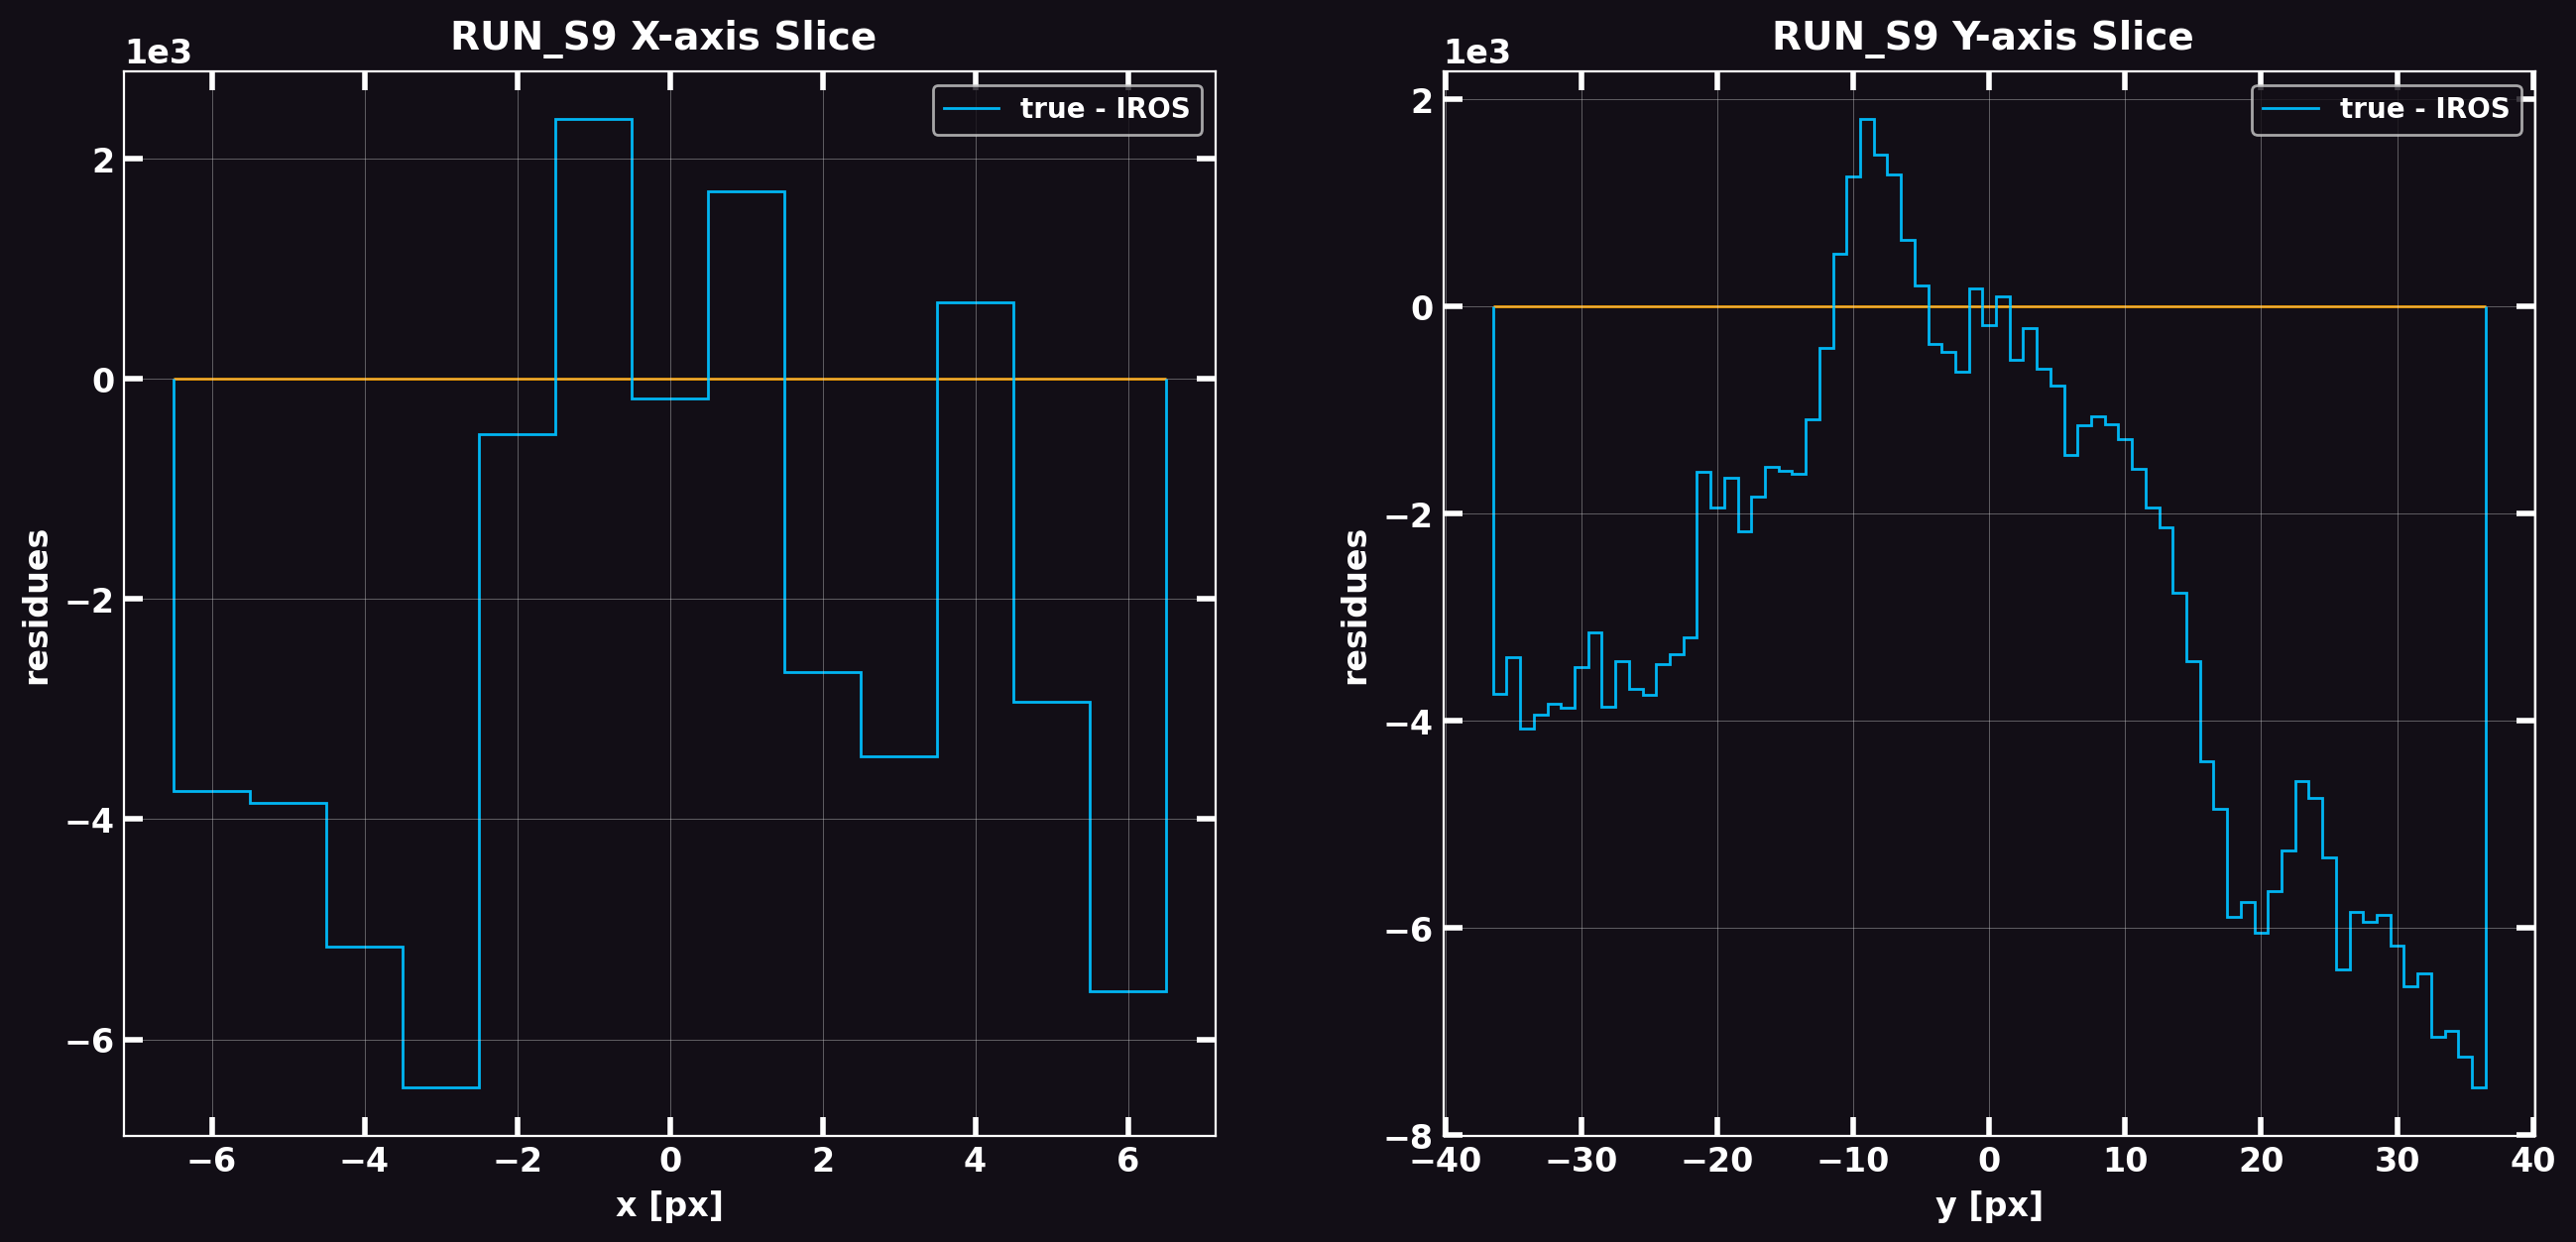

In [9]:
true_sky: NDArray = decode(wfm, detector)

save_to = None  #'/home/edoardo/Desktop/ebands_IROS_run'
plot_results(true_sky, candidates, wfm, save_to=save_to)